In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
%config InlineBackend.figure_format = 'retina'

In [3]:
from pathlib import Path
import numpy as np
from astropy.io import fits
from astropy.table import Table
from matplotlib import pyplot as plt
from kspecdr.inst.isoplane import (
    convert_isoplane_header,
    add_fiber_table,
    write_isoplane_converted_image,
)
from kspecdr.io.image import ImageFile
from kspecdr.preproc.make_im import make_im
from kspecdr.preproc.preproc import reduce_bias, reduce_dark, combine_image
from kspecdr.tlm.make_tlm import read_instrument_data, make_tlm
from kspecdr.extract.make_ex import make_ex
from kspecdr.extract.reduce_arc import reduce_arcs, reduce_arc
from kspecdr.reduce_fflat import reduce_fflat
from scipy.signal import find_peaks_cwt, find_peaks
from matplotlib.lines import Line2D
import logging

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s | %(name)s | %(levelname)s | %(message)s"
)

WD = Path.home() / "Research/kspec/kspecdr"
RESOURCES = WD / "resources"
TESTDIR = RESOURCES / "comm" / "20260129"
CALDIR = TESTDIR / "calib"
CALCONVDIR = CALDIR / "converted"
CONVDIR = TESTDIR / "converted"
PROCDIR = TESTDIR / "processed"
ASSIGNDIR = RESOURCES / "comm" / "assign"

CALCONVDIR.mkdir(exist_ok=True)
CONVDIR.mkdir(exist_ok=True)
PROCDIR.mkdir(exist_ok=True)

mdark_path = RESOURCES / "comm" / "20260130" / "calib" / "mdark_2400s.fits"

In [4]:
logging.getLogger("kspecdr.io.image").setLevel(logging.WARNING)
bias_files = list(CALDIR.glob("Bias*.fits"))
bias_files_converted = [CALCONVDIR / f.name.replace("Bias", "cBias") for f in bias_files]

for bfpath, bfpath_converted in zip(bias_files, bias_files_converted):
    write_isoplane_converted_image(bfpath, bfpath_converted, "BIAS", n_fibers=14)

mbias_path = CALDIR / "mbias.fits"
mbias_file = reduce_bias(bias_files_converted, output_file=mbias_path.as_posix())

2026-02-26 23:28:13,330 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-02-26 23:28:13,348 | astropy | WARNING | TimeDeltaMissingUnitWarning: Numerical value without unit or explicit format passed to TimeDelta, assuming days
2026-02-26 23:28:13,401 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-02-26 23:28:13,424 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-02-26 23:28:13,456 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-02-26 23:28:13,459 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-02-26 23:28:13,478 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-02-26 23:28:13,499 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-02-26 23:28:13,503 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-02-26 23:28:13,520 | kspecdr.inst.isoplane | INFO | Flipped verti

In [5]:
flat_files = list(CALDIR.glob("Flat*.fits"))
flat_files_converted = [CALCONVDIR / f.name.replace("Flat", "cFlat") for f in flat_files]

for fpath, fpath_converted in zip(flat_files, flat_files_converted):
    write_isoplane_converted_image(fpath, fpath_converted, "MFFLAT", n_fibers=14)

for fpath in flat_files_converted:
    make_im(
        fpath.as_posix(),
        cosmic_ray_method="NONE",
        bias_filename=mbias_path.as_posix(),
        use_bias=True,
        verbose=False,
        use_dark=True,
        dark_filename=mdark_path.as_posix(),
    )

2026-02-26 23:28:17,271 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-02-26 23:28:17,281 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-02-26 23:28:17,304 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-02-26 23:28:17,333 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-02-26 23:28:17,337 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-02-26 23:28:17,357 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-02-26 23:28:17,383 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-02-26 23:28:17,386 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-02-26 23:28:17,403 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-02-26 23:28:17,415 | kspecdr.preproc.make_im | INFO | Creating IM file from raw data with TDFIO_CREATEBYCOPY functionality...
2026-02-26 

In [6]:
spec_sets = []
for fpath in flat_files_converted:
    im_path = CALCONVDIR / (fpath.stem + "_im.fits")
    spec_set = fpath.stem[6:13]
    spec_sets.append(spec_set)

    fpath_tlm = CALDIR / ("tlm_" + spec_set + ".fits")
    fpath_ex = CALDIR / (fpath.stem + "_ex.fits")
    args = {
        "IMAGE_FILENAME": im_path.as_posix(),
        "TLMAP_FILENAME": fpath_tlm.as_posix(),
        "EXTRAC_FILENAME": fpath_ex.as_posix(),
    }

    make_tlm(args)
    
    make_ex(args)

2026-02-26 23:28:17,943 | kspecdr.tlm.make_tlm | INFO | Generating tramline map from /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/converted/cFlat_600_450 2026 January 29_im.fits
2026-02-26 23:28:17,954 | kspecdr.tlm.make_tlm | INFO | Instrument code: 99
2026-02-26 23:28:17,955 | kspecdr.tlm.make_tlm | INFO | Starting tramline map generation for non-2DF instrument
2026-02-26 23:28:17,967 | kspecdr.tlm.make_tlm | INFO | Fibres officially in use: 14
2026-02-26 23:28:17,968 | kspecdr.tlm.make_tlm | INFO | Fibres potentially able: 0
2026-02-26 23:28:17,968 | kspecdr.tlm.make_tlm | INFO | Fibres officially dead: 0
2026-02-26 23:28:17,968 | kspecdr.tlm.make_tlm | INFO | Max number of traces: 14
2026-02-26 23:28:17,969 | kspecdr.tlm.make_tlm | INFO | Image dimensions: nspec=1340, nspat=1300
2026-02-26 23:28:17,969 | kspecdr.tlm.make_tlm | INFO | Sweeping image for signs of fibre traces...
2026-02-26 23:28:17,970 | kspecdr.tlm.make_tlm | INFO | Processing column 0/1340 (0.0

In [7]:
spec_sets

['600_450', '150_620', '300_490']

In [8]:
arc_files = list(CALDIR.glob("Arc*.fits"))
arc_files_converted = [CALCONVDIR / f.name.replace("Arc", "cArc") for f in arc_files]

for fpath, fpath_converted in zip(arc_files, arc_files_converted):
    write_isoplane_converted_image(fpath, fpath_converted, "MFARC", n_fibers=14)

    make_im(
        fpath_converted.as_posix(),
        cosmic_ray_method="NONE",
        bias_filename=mbias_path.as_posix(),
        use_bias=True,
        verbose=False,
        use_dark=True,
        dark_filename=mdark_path.as_posix(),
    )

    # hardcoded for now - no 600_680 flat frame
    spec_set = fpath.stem[4:11]
    if spec_set == "600_680":
        spec_set = "600_450"

    fpath_im = CALCONVDIR / (fpath_converted.stem + "_im.fits")
    fpath_ex = CALCONVDIR / (fpath_converted.stem + "_ex.fits")
    tlm_path = CALDIR / ("tlm_" + spec_set + ".fits")
    make_ex(
        {
            "IMAGE_FILENAME": fpath_im.as_posix(),
            "EXTRAC_FILENAME": fpath_ex.as_posix(),
            "TLMAP_FILENAME": tlm_path.as_posix(),
        }
    )

2026-02-26 23:28:20,887 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-02-26 23:28:20,892 | kspecdr.inst.isoplane | INFO | Adding fiber table with 14 fibers
2026-02-26 23:28:20,969 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-02-26 23:28:21,025 | kspecdr.preproc.make_im | INFO | Creating IM file from raw data with TDFIO_CREATEBYCOPY functionality...
2026-02-26 23:28:21,026 | kspecdr.preproc.make_im | INFO | Creating IM file from raw file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/converted/cArc_600_680_360s 2026 January 29.fits -> /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/converted/cArc_600_680_360s 2026 January 29_im.fits
2026-02-26 23:28:21,039 | kspecdr.preproc.make_im | INFO | Instrument: ISOPLANE, SPECTID: UNKNOWN, CLASS: , BITPIX: 16
2026-02-26 23:28:21,051 | kspecdr.preproc.make_im | INFO | Creating variance HDU for raw file
2026-02-26 23:28:21,079 | kspecdr.preproc.m

In [9]:
rwpath_300490 = CALCONVDIR / "cArc_300_490_240s 2026 January 29.fits"
impath_300490 = CALCONVDIR / (rwpath_300490.stem + "_im.fits")
expath_300490 = CALCONVDIR / (rwpath_300490.stem + "_ex.fits")
rdpath_300490 = CALCONVDIR / (rwpath_300490.stem + "_red.fits")

tlm_300 = CALDIR / "tlm_600_430.fits"

args_300490 = {
    "RAW_FILENAME": rwpath_300490.as_posix(),
    "IMAGE_FILENAME": impath_300490.as_posix(),
    "TLMAP_FILENAME": tlm_300.as_posix(),
    "EXTRAC_FILENAME": expath_300490.as_posix(),
    "OUTPUT_FILENAME": rdpath_300490.as_posix(),
    "USE_GENCAL": True,
    "ARCDIR": WD / "data" / "arc_tables",
    "LAMPNAME": "HgArNeKrCd",
}


reduce_arc(args_300490, get_diagnostic=True, diagnostic_dir=CALDIR / "diagnostic")

2026-02-26 23:28:26,972 | kspecdr.extract.reduce_arc | INFO | Using Generic/TAIPAN Calibration Method


2026-02-26 23:28:26,976 | kspecdr.wavecal.arc_io | INFO | Reading arc file /Users/hbahk/Research/kspec/kspecdr/data/arc_tables/HgArNeKrCd.arc
2026-02-26 23:28:26,978 | kspecdr.wavecal.arc_io | INFO | Read 36 arc lines from /Users/hbahk/Research/kspec/kspecdr/data/arc_tables/HgArNeKrCd.arc
2026-02-26 23:28:26,979 | kspecdr.wavecal.calibrate | INFO | Reference fibre: 7
2026-02-26 23:28:26,980 | kspecdr.wavecal.calibrate | INFO | Unique lines: 24
2026-02-26 23:28:26,983 | kspecdr.wavecal.calibrate | INFO | Blend-masked lines: 6 / 24
2026-02-26 23:28:26,985 | kspecdr.wavecal.calibrate | INFO | Sigma: 1.53 pix. Noise: Mean=218.89, SD=153.62
2026-02-26 23:28:26,985 | kspecdr.wavecal.landmarks | INFO | Landmark Registration...
2026-02-26 23:28:26,986 | kspecdr.wavecal.landmarks | INFO | -> Identifying landmarks within each extracted fibre
2026-02-26 23:28:26,995 | kspecdr.wavecal.landmarks | INFO | Tracking arc landmarks from fibre to fibre
2026-02-26 23:28:27,000 | kspecdr.wavecal.landmarks 

In [10]:
diagnostic_dir = CALDIR / "diagnostic"

wavecalid = Table.read(diagnostic_dir / "identified_arcs.dat", format="ascii.fixed_width_two_line")
# coeffs = wavecalid["coeffs"]
x_pts = wavecalid["x_pts"]
y_pts = wavecalid["y_pts"]
residuals = wavecalid["residuals"]
outliers = wavecalid["outliers"].data == "True"

wavecalcoeff = Table.read(diagnostic_dir / "global_fit_coefficients.dat", format="ascii.fixed_width_two_line")
coeffs = wavecalcoeff["coeffs"]

calispec = Table.read(diagnostic_dir / "CALIBRATED_SPECTRA.dat", format="ascii",
                     names=["wave", "flux"])
tempspec = Table.read(diagnostic_dir / "TEMPLATE_SPECTRA.dat", format="ascii.csv",
                     names=["wave", "flux"], delimiter=" ", data_start=0)

resoltab = Table.read(diagnostic_dir / "resolution_per_line.dat", format="ascii.fixed_width_two_line")

<>:37: SyntaxWarning: invalid escape sequence '\A'
<>:37: SyntaxWarning: invalid escape sequence '\A'
/var/folders/c3/0f663kw90xldstvklyr5nq9c0000gn/T/ipykernel_70952/1217721582.py:37: SyntaxWarning: invalid escape sequence '\A'
  ax.text(0.05, 0.95, f"RMS: {rms:.2f} $\AA$", transform=ax.transAxes, ha="left", va="top")
2026-02-26 23:28:30,642 | kspecdr.wavecal.arc_io | INFO | Reading arc file /Users/hbahk/Research/kspec/kspecdr/data/arc_tables/HgArNeKrCd.arc
2026-02-26 23:28:30,643 | kspecdr.wavecal.arc_io | INFO | Read 41 arc lines from /Users/hbahk/Research/kspec/kspecdr/data/arc_tables/HgArNeKrCd.arc


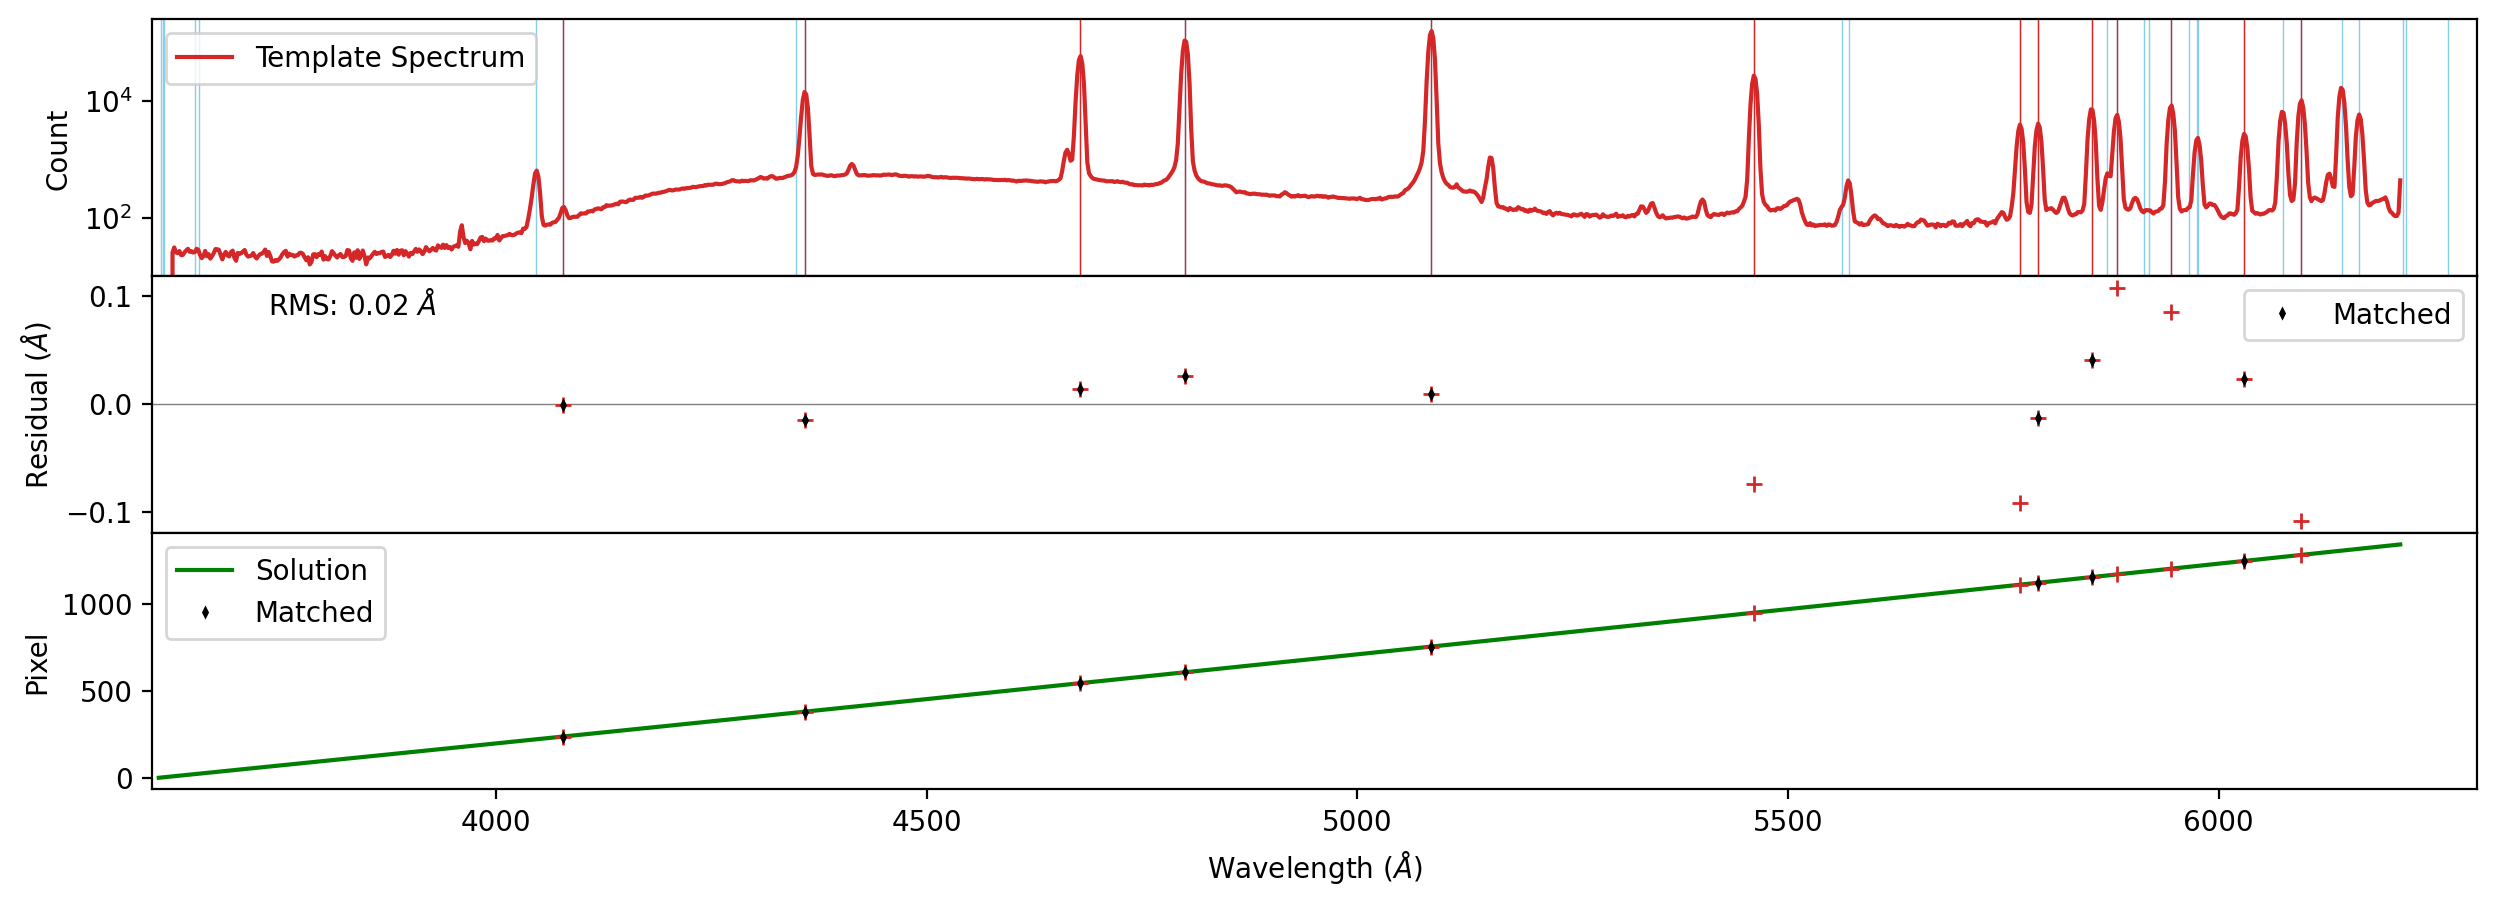

In [11]:
from kspecdr.wavecal.arc_io import read_arc_file

wavetemp = np.polyval(coeffs, np.arange(1340))

xlim = [3600, 6300]

fig, axes = plt.subplots(3, 1, figsize=(15, 5), sharex=True)
ax = axes[0]
# ax.plot(wave, hgarnekrcd_f8, label="Hg(Ar)NeKrCd FIB8", c="k")
# ax.plot(wavetemp, tempspec["flux"], label="Template Spectrum", c="tab:blue")
ax.plot(calispec["wave"], calispec["flux"], label="Template Spectrum", c="tab:red")

nx = 2
xvec = np.array(xlim)
wlist, ilist, labels, nlist = read_arc_file(nx, xvec, "HgArNeKrCd", arc_dir=WD/"data"/"arc_tables")
for i in range(len(wlist)):
    ax.axvline(wlist[i], color="skyblue", lw=0.5, zorder=0)

y_pts_inv = np.polyval(coeffs, x_pts)
for i in range(len(y_pts_inv)):
    ax.axvline(y_pts_inv[i], color="tab:red", lw=0.5, zorder=0)

ax.legend()
ax.set_yscale("log")
ax.set_xlim(xlim)
# ax.set_ylim(-1e4, 7e4)
ax.set_ylabel("Count")

ax = axes[1]
ax.plot(y_pts, residuals, c="tab:red", ls="", marker="+")

ax.plot(y_pts[~outliers], residuals[~outliers], c="k", ls="", marker="d", ms=2, label="Matched")
ax.legend()
ax.axhline(0, c="gray", lw=0.5, zorder=0)
ax.set_ylabel(r"Residual ($\AA$)")
rms = np.sqrt(np.mean(residuals[~outliers]**2))
ax.text(0.05, 0.95, f"RMS: {rms:.2f} $\AA$", transform=ax.transAxes, ha="left", va="top")

ax = axes[2]
xx = np.arange(1340)
yy = np.polyval(coeffs, xx)
ax.plot(yy, xx, label="Solution", c="green")

ax.plot(y_pts, x_pts, c="tab:red", ls="", marker="+")
ax.plot(y_pts[~outliers], x_pts[~outliers], c="k", ls="", marker="d", ms=2, label="Matched")
ax.legend()
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Pixel")
ax.set_xlim(xlim)

ax.legend()

# for ax in axes:
#     # minor ticks direction in
#     ax.minorticks_on()
#     ax.tick_params(which="both", direction="in")
#     ax.tick_params(which="major", length=6)
#     ax.tick_params(which="minor", length=3)

fig.subplots_adjust(hspace=0.0)


<>:7: SyntaxWarning: invalid escape sequence '\A'
<>:7: SyntaxWarning: invalid escape sequence '\A'
/var/folders/c3/0f663kw90xldstvklyr5nq9c0000gn/T/ipykernel_70952/3731827753.py:7: SyntaxWarning: invalid escape sequence '\A'
  ax.set_ylabel("FWHM ($\AA$)")


Text(0, 0.5, 'R')

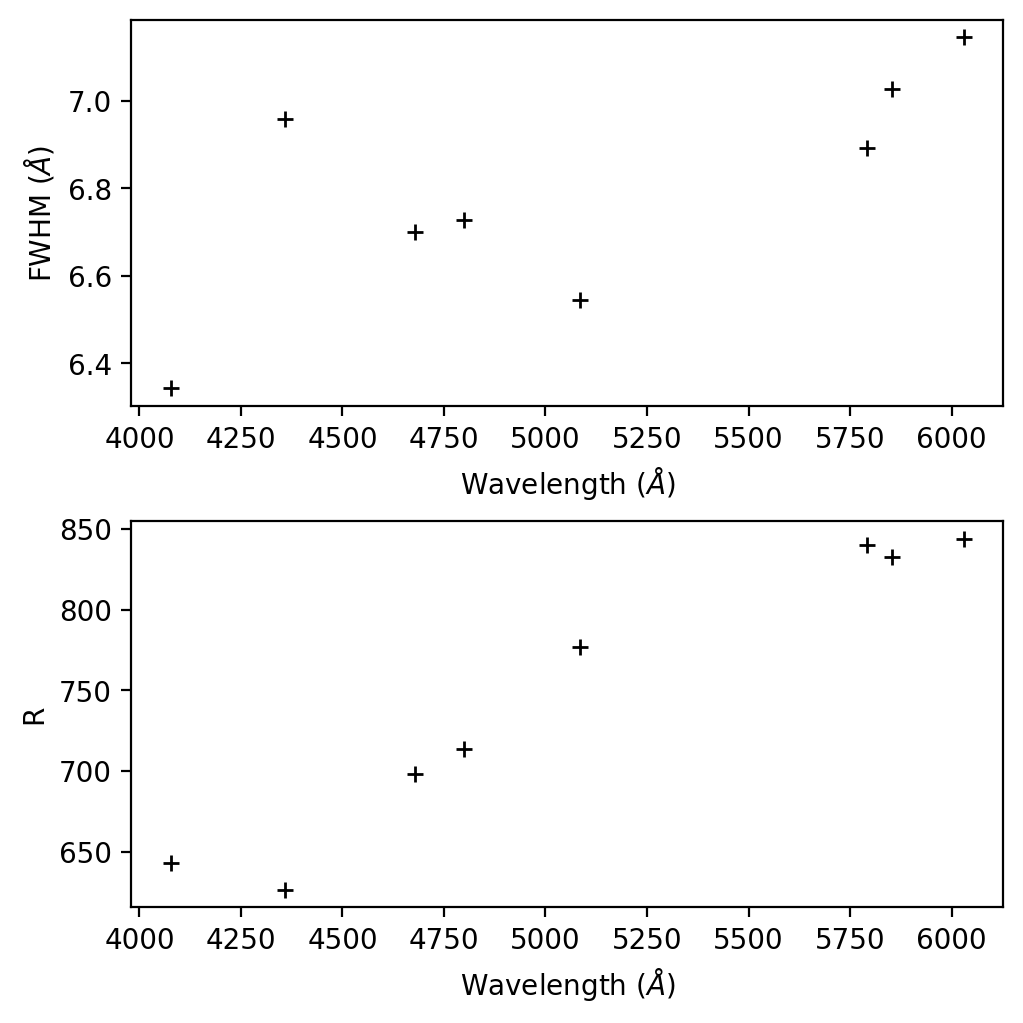

In [12]:
fig = plt.figure(figsize=(5, 5), constrained_layout=True)
ax = fig.add_subplot(211)
ax.plot(resoltab["wavelength"], resoltab["fwhm_angstrom"], c="k", ls="", marker="+")
# ax.set_xlim(5000, 8100)
# ax.set_ylim(0, 1.5)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("FWHM ($\AA$)")
ax = fig.add_subplot(212)
ax.plot(resoltab["wavelength"], resoltab["resolving_power"], c="k", ls="", marker="+")
# ax.set_xlim(5000, 8100)
# ax.set_ylim(0, 1.5)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("R")

In [13]:
colnames = ["fiber_ID", "target_x", "target_y", "target_ra", "target_dec", "target_rank", "target_class"]
assign_table = Table.read(ASSIGNDIR / "tile_059.assign.txt", names=colnames, format='ascii')
# fiber table columns for kspecdr
assign_table["TYPE"] = "N"
# assign_table["TYPE"][assign_table["target_class"] == 9] = "S"
assign_table["TYPE"][np.isin(assign_table["target_class"], [0])] = "P" # This is only for Dr. Chun's tiles, where the target_class represents priority of target stars
assign_table["TYPE"][np.isin(assign_table["target_class"], [1, 2, 9])] = "S" # The other targets were failed to be assignedb (1, 2)
assign_table["TYPE"][np.isin(assign_table["target_class"], [8])] = "C"
assign_table["NAME"] = np.array([f"FIB{i}" for i in assign_table["fiber_ID"]])
assign_table

fiber_ID,target_x,target_y,target_ra,target_dec,target_rank,target_class,TYPE,NAME
int64,float64,float64,float64,float64,float64,int64,str1,str5
1,15.551,75.494,158.918808,-44.239109,17.241,1,S,FIB1
2,-34.129,72.128,158.154726,-44.200641,14.351,2,S,FIB2
3,-84.749,72.43,157.386216,-44.192119,13.294,8,C,FIB3
4,-16.425,54.691,158.426799,-44.011591,15.756,1,S,FIB4
5,29.911,41.136,159.138723,-43.861368,16.441,1,S,FIB5
6,-29.228,8.777,158.232459,-43.503346,14.016,2,S,FIB6
7,77.395,2.591,159.854612,-43.429411,13.399,2,S,FIB7
8,11.676,11.313,158.858221,-43.532308,13.432,0,P,FIB8
9,-73.196,0.185,157.567683,-43.40352,15.946,1,S,FIB9


## Reduce commissioning flats with `reduce_fflat` (blocker check)

Run `reduce_fflat` on each commissioning flat setup (150_620, 300_490, 600_450) and inspect whether outputs are usable for object flat-fielding work.

In [14]:
arc_raw_by_spec = {
    "150_620": CALCONVDIR / "cArc_150_620_210s 2026 January 29.fits",
    "300_490": CALCONVDIR / "cArc_300_490_240s 2026 January 29.fits",
    "600_450": CALCONVDIR / "cArc_600_450_120s 2026 January 29.fits",
}

flat_raw_files = sorted(CALCONVDIR.glob("cFlat_* 2026 January 29.fits"))
fflat_jobs = []

for flat_raw in flat_raw_files:
    spec_set = flat_raw.name.split()[0].replace("cFlat_", "")
    if spec_set not in arc_raw_by_spec:
        print(f"Skipping {flat_raw.name}: no arc mapping for {spec_set}")
        continue

    flat_im = CALCONVDIR / f"{flat_raw.stem}_im.fits"
    flat_ex = CALCONVDIR / f"{flat_raw.stem}_ex.fits"
    tlm_path = CALDIR / f"tlm_{spec_set}.fits"

    arc_raw = arc_raw_by_spec[spec_set]
    arc_im = CALCONVDIR / f"{arc_raw.stem}_im.fits"
    arc_ex = CALCONVDIR / f"{arc_raw.stem}_ex.fits"
    arc_red = CALCONVDIR / f"{arc_raw.stem}_red.fits"

    if not arc_red.exists():
        reduce_arc(
            {
                "RAW_FILENAME": arc_raw.as_posix(),
                "IMAGE_FILENAME": arc_im.as_posix(),
                "EXTRAC_FILENAME": arc_ex.as_posix(),
                "OUTPUT_FILENAME": arc_red.as_posix(),
                "TLMAP_FILENAME": tlm_path.as_posix(),
                "USE_GENCAL": True,
                "ARCDIR": WD / "data" / "arc_tables",
                "LAMPNAME": "HgArNeKrCd",
            },
            get_diagnostic=False,
        )

    fflat_red = CALDIR / f"fflat_{spec_set}_red.fits"
    reduce_fflat(
        {
            "EXTRAC_FILENAME": flat_ex.as_posix(),
            "OUTPUT_FILENAME": fflat_red.as_posix(),
            "WAVEL_FILENAME": arc_red.as_posix(),
            "DO_TLMAP": False,
            "DO_EXTRA": False,
            "DO_REDFL": True,
            "TRUNCFLAT": True,
            "USEFLATSTART": 30,
            "USEFLATEND": 1310,
            "LAF_FLAG": False,
            "BSSMOOTH": False,
            "VERBOSE": False,
        }
    )

    fflat_jobs.append(
        {
            "spec_set": spec_set,
            "flat_raw": flat_raw,
            "flat_im": flat_im,
            "flat_ex": flat_ex,
            "tlm": tlm_path,
            "arc_raw": arc_raw,
            "arc_red": arc_red,
            "fflat_red": fflat_red,
        }
    )

fflat_jobs


2026-02-26 23:28:31,511 | kspecdr.reduce_fflat | INFO | Reducing flat spectra data from /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/converted/cFlat_150_620 2026 January 29_ex.fits
2026-02-26 23:28:31,513 | kspecdr.wavecal.scrunch | INFO | Scrunching tmp_mfsfff.fits using /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/converted/cArc_150_620_210s 2026 January 29_red.fits (Reverse=False)


2026-02-26 23:28:31,555 | kspecdr.reduce_fflat | INFO | 14 good fibres used to make flat field
2026-02-26 23:28:31,566 | kspecdr.wavecal.scrunch | INFO | Scrunching tmp_mfsfff.fits using /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/converted/cArc_150_620_210s 2026 January 29_red.fits (Reverse=True)
2026-02-26 23:28:31,627 | kspecdr.reduce_fflat | INFO | Fibre Flat Frame Reduced: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/fflat_150_620_red.fits
2026-02-26 23:28:31,627 | kspecdr.reduce_fflat | INFO | Reducing flat spectra data from /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/converted/cFlat_300_490 2026 January 29_ex.fits
2026-02-26 23:28:31,629 | kspecdr.wavecal.scrunch | INFO | Scrunching tmp_mfsfff.fits using /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/converted/cArc_300_490_240s 2026 January 29_red.fits (Reverse=False)
2026-02-26 23:28:31,664 | kspecdr.reduce_fflat | INFO | 14 good fibres used to 

[{'spec_set': '150_620',
  'flat_raw': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/converted/cFlat_150_620 2026 January 29.fits'),
  'flat_im': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/converted/cFlat_150_620 2026 January 29_im.fits'),
  'flat_ex': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/converted/cFlat_150_620 2026 January 29_ex.fits'),
  'tlm': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/tlm_150_620.fits'),
  'arc_raw': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/converted/cArc_150_620_210s 2026 January 29.fits'),
  'arc_red': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/converted/cArc_150_620_210s 2026 January 29_red.fits'),
  'fflat_red': PosixPath('/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/fflat_150_620_red.fits')},
 {'spec_set': '300_490',
  'flat_raw': Po

In [15]:
summary_rows = []
for job in fflat_jobs:
    with fits.open(job["flat_ex"]) as hdu_ex, fits.open(job["fflat_red"]) as hdu_red:
        ex_data = np.asarray(hdu_ex[0].data, dtype=float)
        red_data = np.asarray(hdu_red[0].data, dtype=float)

        summary_rows.append(
            (
                job["spec_set"],
                str(job["fflat_red"]),
                str(ex_data.shape),
                str(red_data.shape),
                bool(ex_data.shape == red_data.shape),
                "WAVELA" in hdu_red,
                hdu_red[0].header.get("SCRUNCH", None),
                float(np.nanmean(np.isfinite(red_data))),
                float(np.nanmedian(np.nanmedian(red_data, axis=1))),
                float(np.nanstd(np.nanmedian(red_data, axis=1))),
            )
        )

fflat_summary = Table(
    rows=summary_rows,
    names=[
        "spec_set",
        "fflat_red",
        "ex_shape",
        "red_shape",
        "shape_match",
        "has_wavela",
        "scrunch_flag",
        "finite_fraction",
        "fiber_median_med",
        "fiber_median_std",
    ],
)
fflat_summary


spec_set,fflat_red,ex_shape,red_shape,shape_match,has_wavela,scrunch_flag,finite_fraction,fiber_median_med,fiber_median_std
str7,str88,str10,str10,bool,bool,bool,float64,float64,float64
150_620,/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/fflat_150_620_red.fits,"(14, 1340)","(14, 1340)",True,True,True,1.0,1.000007003545761,0.0003835581612942066
300_490,/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/fflat_300_490_red.fits,"(14, 1340)","(14, 1340)",True,True,True,1.0,1.0001648962497711,0.0007013730629792294
600_450,/Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/fflat_600_450_red.fits,"(14, 1340)","(14, 1340)",True,True,True,1.0,1.0001152157783508,0.0008123903488133228


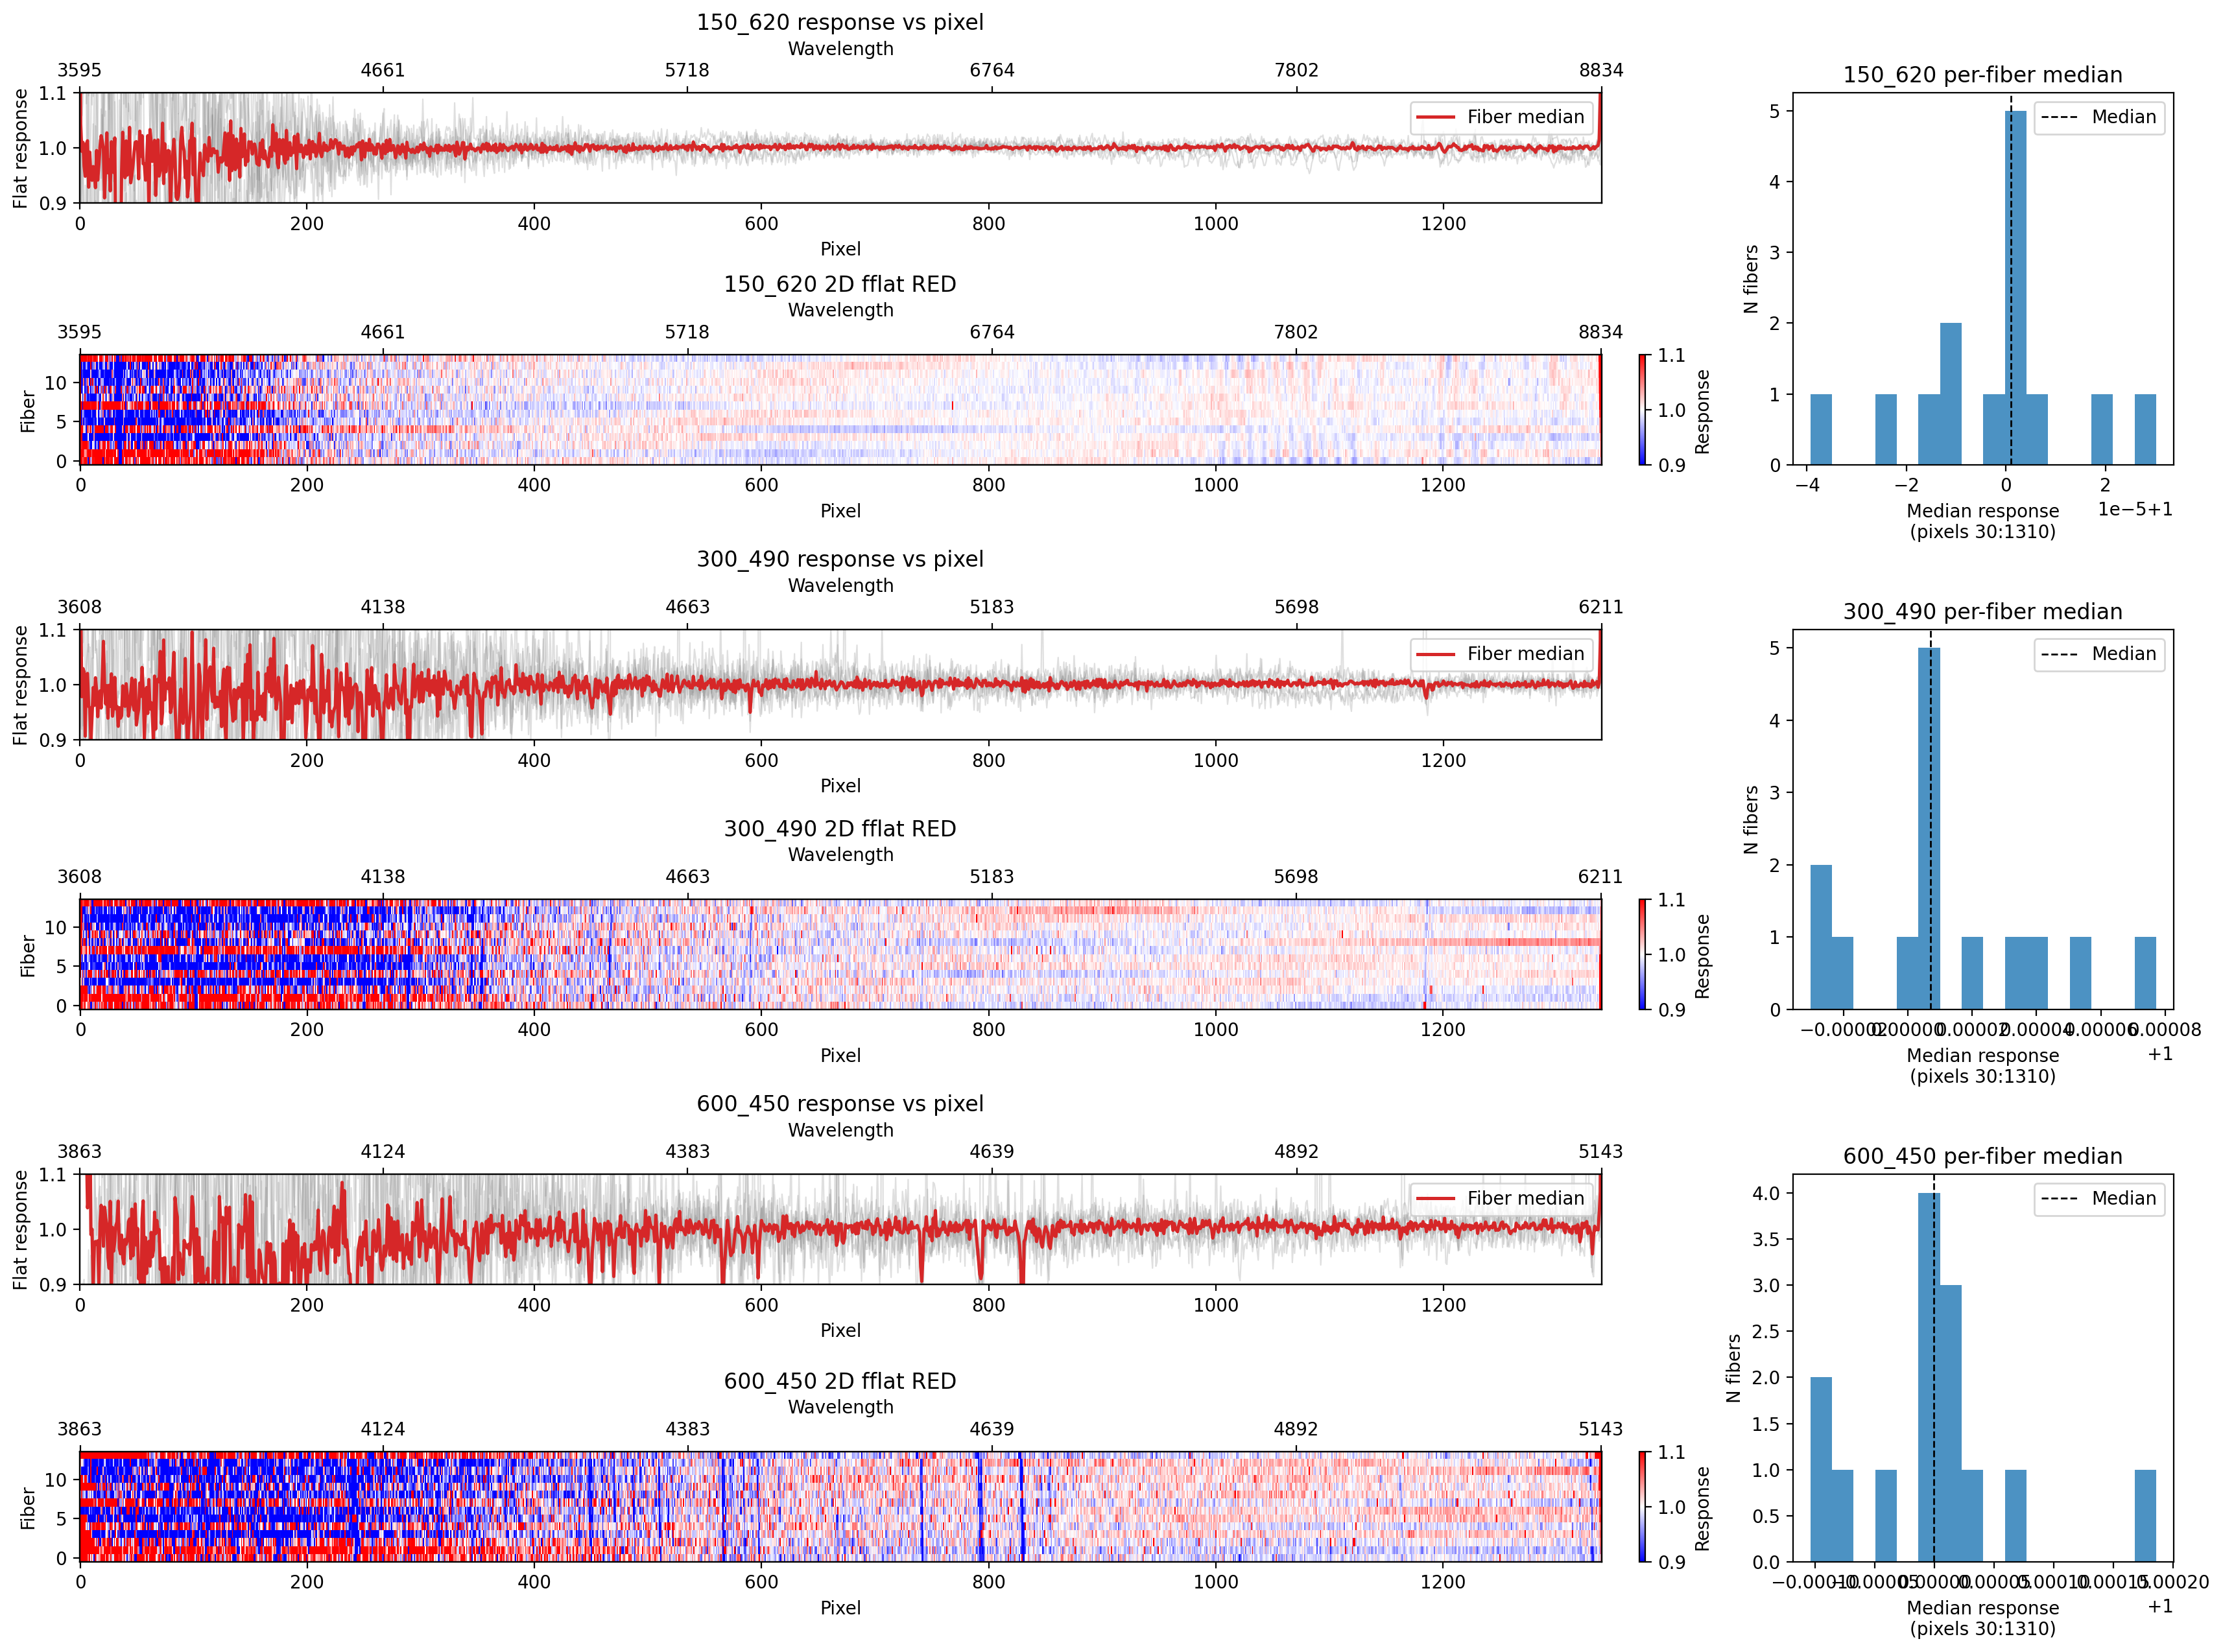

In [16]:
nset = len(fflat_jobs)
if nset == 0:
    raise RuntimeError("No reduce_fflat outputs found. Run the previous cell first.")

fig = plt.figure(figsize=(17, 4.2 * max(1, nset)), constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.03, h_pad=0.03, wspace=0.02, hspace=0.02)
gs = fig.add_gridspec(2 * nset, 3, width_ratios=[2, 2, 1])

for i, job in enumerate(fflat_jobs):
    with fits.open(job["fflat_red"]) as hdul:
        red = np.asarray(hdul[0].data, dtype=float)

    npix = red.shape[1]
    xpix = np.arange(npix)

    median_spec = np.nanmedian(red, axis=0)
    sample_idx = np.linspace(0, red.shape[0] - 1, 5, dtype=int)

    # Derive wavelength solution for a reference fiber from the arc file
    wave_ref = None
    try:
        with ImageFile(job["arc_red"].as_posix(), mode="READ") as arc_file:
            wave_data = arc_file.read_wave_data()
        if wave_data is not None and wave_data.shape[1] == npix:
            ref_fiber = wave_data.shape[0] // 2
            wave_ref = wave_data[ref_fiber]
    except Exception:
        wave_ref = None

    # Rows used by this spec_set
    row_top = 2 * i
    row_bottom = 2 * i + 1

    # Left panel (L): response vs pixel, on the top row, spanning first two columns
    ax_left = fig.add_subplot(gs[row_top, :2])
    for fib_idx in sample_idx:
        ax_left.plot(xpix, red[fib_idx], alpha=0.25, lw=0.8, color="gray")
    ax_left.plot(xpix, median_spec, lw=1.8, color="tab:red", label="Fiber median")
    ax_left.set_title(f"{job['spec_set']} response vs pixel")
    ax_left.set_ylabel("Flat response")
    ax_left.set_xlabel("Pixel")
    ax_left.legend(loc="upper right")
    ax_left.set_ylim(0.9, 1.1)
    ax_left.set_xlim(0, npix - 1)

    # Add wavelength axis on top using the reference fiber
    if wave_ref is not None:
        ax_left_wave = ax_left.twiny()
        ax_left_wave.set_xlim(ax_left.get_xlim())
        tick_pix = np.linspace(0, npix - 1, 6, dtype=int)
        tick_wave = wave_ref[tick_pix]
        ax_left_wave.set_xticks(tick_pix)
        ax_left_wave.set_xticklabels([f"{w:.0f}" for w in tick_wave])
        ax_left_wave.set_xlabel("Wavelength")

    # Right-bottom panel (R): 2D fflat RED image, on the bottom row, spanning first two columns
    ax_right = fig.add_subplot(gs[row_bottom, :2])
    # vmin, vmax = np.nanpercentile(red, [1, 99])
    vmin, vmax = 0.9, 1.1
    im = ax_right.imshow(red, origin="lower", aspect="auto", cmap="bwr", vmin=vmin, vmax=vmax, interpolation="none")
    ax_right.set_title(f"{job['spec_set']} 2D fflat RED")
    ax_right.set_xlabel("Pixel")
    ax_right.set_ylabel("Fiber")
    cbar = fig.colorbar(im, ax=ax_right, fraction=0.1, pad=0.01)
    cbar.set_label("Response")

    # Add wavelength axis on top of the image panel using the same reference fiber
    if wave_ref is not None:
        ax_right_wave = ax_right.twiny()
        ax_right_wave.set_xlim(ax_right.get_xlim())
        tick_pix = np.linspace(0, npix - 1, 6, dtype=int)
        tick_wave = wave_ref[tick_pix]
        ax_right_wave.set_xticks(tick_pix)
        ax_right_wave.set_xticklabels([f"{w:.0f}" for w in tick_wave])
        ax_right_wave.set_xlabel("Wavelength")

    # Middle panel (M): per-fiber median histogram, spanning both rows in the right column
    ax_mid = fig.add_subplot(gs[row_top:row_bottom + 1, 2])
    fiber_median = np.nanmedian(red[:, 30:1310], axis=1)
    fiber_median = fiber_median[np.isfinite(fiber_median)]
    ax_mid.hist(fiber_median, bins=16, color="tab:blue", alpha=0.8)
    ax_mid.axvline(np.nanmedian(fiber_median), color="k", lw=1, ls="--", label="Median")
    ax_mid.set_title(f"{job['spec_set']} per-fiber median")
    ax_mid.set_xlabel("Median response\n(pixels 30:1310)")
    ax_mid.set_ylabel("N fibers")
    ax_mid.legend(loc="upper right")

plt.show()


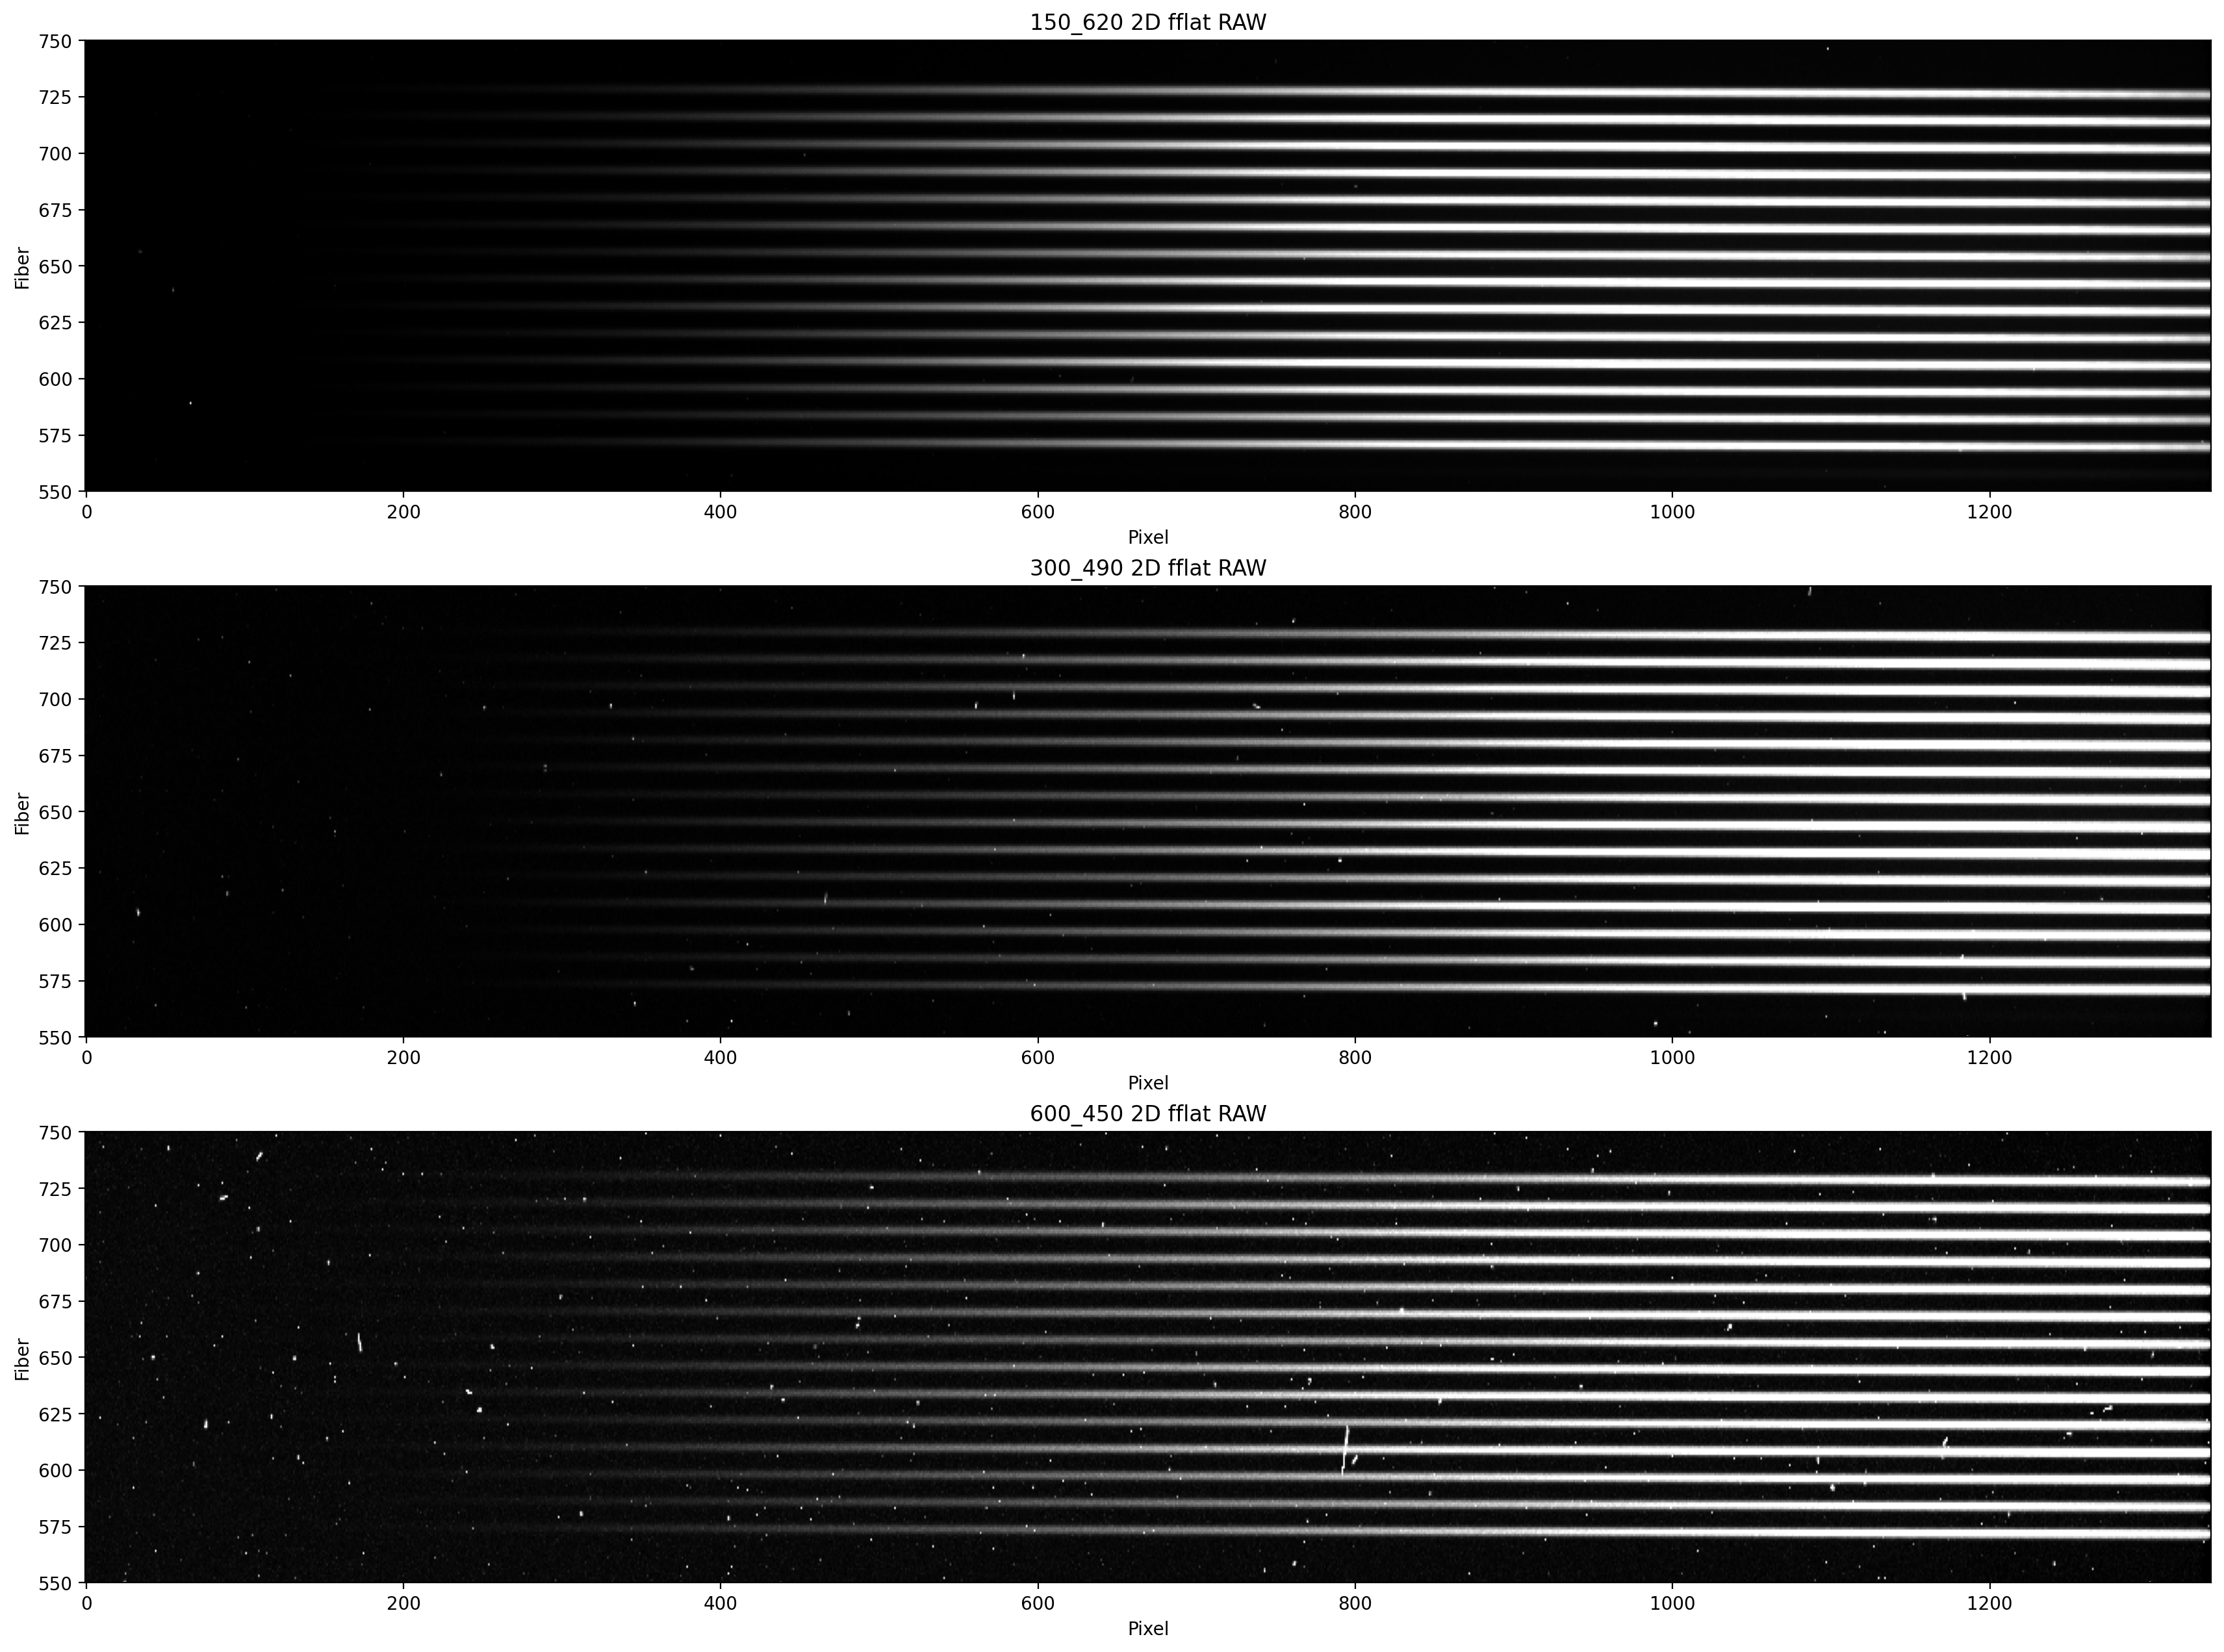

In [17]:
fig = plt.figure(figsize=(17, 4.2 * max(1, nset)), constrained_layout=True)

for i, job in enumerate(fflat_jobs):
    with fits.open(job["flat_raw"]) as hdul:
        raw = np.asarray(hdul[0].data, dtype=float)
    
    ax = fig.add_subplot(nset, 1, i + 1)
    vmin, vmax = np.nanpercentile(raw, [1, 99])
    ax.imshow(raw, origin="lower", aspect="auto", cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(f"{job['spec_set']} 2D fflat RAW")
    ax.set_xlabel("Pixel")
    ax.set_ylabel("Fiber")
    ax.set_ylim(550, 750)

## Reduce Object Science Frame with `reduce_object`

Reduce the `tile_059` science frames from the January 29 commissioning run using `reduce_object`:

- **Throughput calibration**: `SKYLINE(KGB)` — Karl Glazebrook's sky-line robust-slope algorithm
- **Flux calibration**: ATLAS Refcat2 standard-star catalog + BOSZ stellar templates (`CALIBFLUX=True`)
- **Intermediate products**: `RWSS` (pre-sky-subtracted), `SKY`, and `THPUT` extensions are saved for inspection

The standard star in `tile_059` is fiber 3 (0-indexed: 2, class 8 in the assignment), matched to the Refcat2 entry in `standard_star_atlas_refcat2.csv`.

In [18]:
from kspecdr.reduce_object import reduce_object
from kspecdr.fluxcal.qc import (
    plot_calibration_summary,
    plot_per_star_vectors,
    plot_calibration_residuals,
    plot_photometric_residuals,
    summarize_calibration,
)
from kspecdr.fluxcal.calibration import (
    compute_calibration_vector_for_star,
    combine_calibration_vectors,
)
from kspecdr.fluxcal.photometry import (
    load_filter_curves,
    load_standard_star_catalog,
    photometry_from_catalog_row,
    DEFAULT_BANDS,
)
from kspecdr.fluxcal.templates import TemplateLibrary, prepare_template
from kspecdr.fluxcal.masks import load_mask_regions
from kspecdr.fluxcal.containers import Spectrum1D
from kspecdr.constants import FIBER_TYPE_CALIBRATION

CATALOG = CALDIR / "standard_star_atlas_refcat2.csv"

# Arc RED files produced by the fflat setup cell above
arc_red_by_spec = {
    "150_620": CALCONVDIR / "cArc_150_620_210s 2026 January 29_red.fits",
    "300_490": CALCONVDIR / "cArc_300_490_240s 2026 January 29_red.fits",
    "600_450": CALCONVDIR / "cArc_600_450_120s 2026 January 29_red.fits",
}

# --- Convert tile_059 raw science frames and run make_im ---
tile059_files = sorted(TESTDIR.glob("tile_059*.fits"))
obj_jobs = []

for fpath in tile059_files:
    fpath_converted = CONVDIR / fpath.name.replace("tile_059", "ctile_059")
    im_path = CONVDIR / (fpath_converted.stem + "_im.fits")
    ex_path = CONVDIR / (fpath_converted.stem + "_ex.fits")

    write_isoplane_converted_image(fpath, fpath_converted, "OBJECT", fiber_table=assign_table)

    make_im(
        fpath_converted.as_posix(),
        cosmic_ray_method="NONE",
        bias_filename=mbias_path.as_posix(),
        use_bias=True,
        verbose=False,
        use_dark=True,
        dark_filename=mdark_path.as_posix(),
    )

    # Determine spectral setup from IM file header (GRATID + LAMBDAC)
    with ImageFile(im_path.as_posix()) as img:
        grating = img.get_header_value("GRATID")
        lambdac = float(img.get_header_value("LAMBDAC"))
        spec_set = f"{grating}_{lambdac/10:.0f}"

    tlm_path = CALDIR / f"tlm_{spec_set}.fits"
    fflat_path = CALDIR / f"fflat_{spec_set}_red.fits"
    arc_red_path = arc_red_by_spec.get(spec_set)

    if arc_red_path is None:
        print(f"WARNING: no arc file for spec_set={spec_set!r} — scrunch will be skipped")

    red_path = PROCDIR / f"{fpath_converted.stem}_red.fits"

    obj_jobs.append({
        "spec_set": spec_set,
        "raw": fpath,
        "converted": fpath_converted,
        "im": im_path,
        "ex": ex_path,
        "tlm": tlm_path,
        "fflat": fflat_path,
        "arc_red": arc_red_path,
        "red": red_path,
    })
    print(f"  {fpath.name}  →  spec_set={spec_set}")

print(f"\nReady to reduce {len(obj_jobs)} tile_059 science frame(s)")

2026-02-26 23:28:36,315 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-02-26 23:28:36,330 | astropy | WARNING | TimeDeltaMissingUnitWarning: Numerical value without unit or explicit format passed to TimeDelta, assuming days
2026-02-26 23:28:36,333 | kspecdr.inst.isoplane | INFO | Adding fiber table with None fibers
2026-02-26 23:28:36,333 | kspecdr.inst.isoplane | WARNING | Fiber table has 14 rows, but n_fibers=None were given. Ignoring n_fibers argument.
2026-02-26 23:28:36,357 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-02-26 23:28:36,369 | kspecdr.preproc.make_im | INFO | Creating IM file from raw data with TDFIO_CREATEBYCOPY functionality...
2026-02-26 23:28:36,369 | kspecdr.preproc.make_im | INFO | Creating IM file from raw file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/converted/ctile_059 2026 January 29 17_28_46 1.fits -> /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/converted/ctil

  tile_059 2026 January 29 17_28_46 1.fits  →  spec_set=300_490


2026-02-26 23:28:36,794 | kspecdr.inst.isoplane | INFO | Readout settings: speed=0 MHz, gain=HIGH, noise=LOW
2026-02-26 23:28:36,797 | kspecdr.inst.isoplane | INFO | Adding fiber table with None fibers
2026-02-26 23:28:36,797 | kspecdr.inst.isoplane | WARNING | Fiber table has 14 rows, but n_fibers=None were given. Ignoring n_fibers argument.
2026-02-26 23:28:36,815 | kspecdr.inst.isoplane | INFO | Flipped vertical orientation
2026-02-26 23:28:36,827 | kspecdr.preproc.make_im | INFO | Creating IM file from raw data with TDFIO_CREATEBYCOPY functionality...
2026-02-26 23:28:36,827 | kspecdr.preproc.make_im | INFO | Creating IM file from raw file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/converted/ctile_059 2026 January 29 18_09_46 3.fits -> /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/converted/ctile_059 2026 January 29 18_09_46 3_im.fits
2026-02-26 23:28:36,840 | kspecdr.preproc.make_im | INFO | Instrument: ISOPLANE, SPECTID: UNKNOWN, CLASS: , BITPIX: 1

  tile_059 2026 January 29 17_49_30 2.fits  →  spec_set=300_490


2026-02-26 23:28:37,054 | kspecdr.preproc.make_im | INFO | Successfully created IM file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/converted/ctile_059 2026 January 29 18_09_46 3_im.fits
2026-02-26 23:28:37,165 | kspecdr.preproc.make_im | INFO | 0.00% of pixels were saturated
2026-02-26 23:28:37,220 | kspecdr.preproc.make_im | INFO | Bias subtraction method: MASTER
2026-02-26 23:28:37,241 | kspecdr.preproc.make_im | INFO | Subtracted bias level (from bias frame): 612.80
2026-02-26 23:28:37,242 | kspecdr.preproc.make_im | INFO | No overscan region information provided; skipping overscan-based refinement of bias subtraction
2026-02-26 23:28:37,251 | kspecdr.preproc.make_im | INFO | Object exposure time: 1200.0
2026-02-26 23:28:37,252 | kspecdr.preproc.make_im | INFO | Dark exposure time: 2400.0
2026-02-26 23:28:37,252 | kspecdr.preproc.make_im | INFO | Dark scaled by: 0.5
2026-02-26 23:28:37,262 | kspecdr.preproc.make_im | INFO | Variance HDU created and initialized


  tile_059 2026 January 29 18_09_46 3.fits  →  spec_set=300_490

Ready to reduce 3 tile_059 science frame(s)


In [19]:
for job in obj_jobs:
    print(f"\nReducing: {job['raw'].name}")

    args = {
        # IM → EX pipeline (make_ex runs inside reduce_object using IMAGE_FILENAME)
        "IMAGE_FILENAME":  job["im"].as_posix(),
        "EXTRAC_FILENAME": job["ex"].as_posix(),
        "OUTPUT_FILENAME": job["red"].as_posix(),
        # Calibration files
        "TLMAP_FILENAME":  job["tlm"].as_posix(),
        "FFLAT_FILENAME":  job["fflat"].as_posix(),
        "WAVEL_FILENAME":  job["arc_red"].as_posix() if job["arc_red"] else "",
        # Throughput calibration: Karl Glazebrook sky-line robust-slope algorithm
        # "TPMETH": "SKYLINE(KGB)",
        "TPMETH": "OFF",
        # Save pre-sky-subtraction snapshot for later inspection
        "INC_RWSS": True,
        # Sky subtraction (mean combination of sky fibers)
        "SKYSUB": True,
        # "SKYSUB_METHOD": "MEDIAN",
        "SKYCOMBINE": "SIGCLIP",
        "SKYCOMBINE_SIGMA": 3.0,
        "SKYCOMBINE_NITER": 15,
        # Flux calibration with Refcat2 standard-star catalog + BOSZ templates
        "CALIBFLUX": False,
        "CALIBFLUX_CATALOG": CATALOG.as_posix(),
        "CALIBFLUX_METRIC": "chi2",
        "VERBOSE": True,
    }

    reduce_object(args)
    print(f"  ✓  Written: {job['red']}")

2026-02-26 23:28:37,335 | kspecdr.reduce_object | WARNING | RAW_FILENAME not in args; skipping MAKE_IM (assuming IM file already exists)


2026-02-26 23:28:37,336 | kspecdr.extract.make_ex | INFO | Extracting /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/converted/ctile_059 2026 January 29 17_28_46 1_im.fits -> /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/converted/ctile_059 2026 January 29 17_28_46 1_ex.fits using TLM /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/calib/tlm_300_490.fits
2026-02-26 23:28:37,337 | kspecdr.extract.make_ex | INFO | Extraction Method: TRAM
2026-02-26 23:28:37,361 | kspecdr.extract.make_ex | INFO | Performing SUM extraction with width=10.0



Reducing: tile_059 2026 January 29 17_28_46 1.fits


Summing extraction: 100%|██████████| 1340/1340 [00:00<00:00, 1772.11pixel/s]
2026-02-26 23:28:38,140 | kspecdr.extract.make_ex | INFO | Written extracted file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/converted/ctile_059 2026 January 29 17_28_46 1_ex.fits
2026-02-26 23:28:38,141 | kspecdr.reduce_object | INFO | ==================================================
2026-02-26 23:28:38,142 | kspecdr.reduce_object | INFO | Reducing object spectra from extraction file
2026-02-26 23:28:38,142 | kspecdr.reduce_object | INFO | ==================================================
2026-02-26 23:28:38,143 | kspecdr.reduce_object | INFO | Extraction file = /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/converted/ctile_059 2026 January 29 17_28_46 1_ex.fits
2026-02-26 23:28:38,143 | kspecdr.reduce_object | INFO | Creating RED file /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/processed/ctile_059 2026 January 29 17_28_46 1_red.fits from /Users/hbahk/Research

  ✓  Written: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/processed/ctile_059 2026 January 29 17_28_46 1_red.fits

Reducing: tile_059 2026 January 29 17_49_30 2.fits


Summing extraction: 100%|██████████| 1340/1340 [00:00<00:00, 1817.29pixel/s]
2026-02-26 23:28:39,139 | kspecdr.extract.make_ex | INFO | Written extracted file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/converted/ctile_059 2026 January 29 17_49_30 2_ex.fits
2026-02-26 23:28:39,140 | kspecdr.reduce_object | INFO | ==================================================
2026-02-26 23:28:39,140 | kspecdr.reduce_object | INFO | Reducing object spectra from extraction file
2026-02-26 23:28:39,141 | kspecdr.reduce_object | INFO | ==================================================
2026-02-26 23:28:39,141 | kspecdr.reduce_object | INFO | Extraction file = /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/converted/ctile_059 2026 January 29 17_49_30 2_ex.fits
2026-02-26 23:28:39,142 | kspecdr.reduce_object | INFO | Creating RED file /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/processed/ctile_059 2026 January 29 17_49_30 2_red.fits from /Users/hbahk/Research

  ✓  Written: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/processed/ctile_059 2026 January 29 17_49_30 2_red.fits

Reducing: tile_059 2026 January 29 18_09_46 3.fits


Summing extraction: 100%|██████████| 1340/1340 [00:00<00:00, 1829.82pixel/s]
2026-02-26 23:28:40,113 | kspecdr.extract.make_ex | INFO | Written extracted file: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/converted/ctile_059 2026 January 29 18_09_46 3_ex.fits
2026-02-26 23:28:40,114 | kspecdr.reduce_object | INFO | ==================================================
2026-02-26 23:28:40,115 | kspecdr.reduce_object | INFO | Reducing object spectra from extraction file
2026-02-26 23:28:40,115 | kspecdr.reduce_object | INFO | ==================================================
2026-02-26 23:28:40,115 | kspecdr.reduce_object | INFO | Extraction file = /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/converted/ctile_059 2026 January 29 18_09_46 3_ex.fits
2026-02-26 23:28:40,116 | kspecdr.reduce_object | INFO | Creating RED file /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/processed/ctile_059 2026 January 29 18_09_46 3_red.fits from /Users/hbahk/Research

  ✓  Written: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/processed/ctile_059 2026 January 29 18_09_46 3_red.fits


Filename: /Users/hbahk/Research/kspec/kspecdr/resources/comm/20260129/processed/ctile_059 2026 January 29 17_28_46 1_red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     181   (1340, 14)   float32   
  1  VARIANCE      1 ImageHDU         8   (1340, 14)   float32   
  2  WAVELA        1 ImageHDU         8   (1340, 14)   float32   
  3  FIBRES        1 BinTableHDU     27   14R x 9C   [K, D, D, D, D, D, K, 1A, 5A]   
  4  THPUT         1 ImageHDU         7   (14,)   float32   
  5  RWSS          1 ImageHDU         8   (1340, 14)   float32   
  6  RWSSVAR       1 ImageHDU         8   (1340, 14)   float32   
  7  SKY           1 ImageHDU         7   (1340,)   float32   
  8  SKYVAR        1 ImageHDU         7   (1340,)   float32   


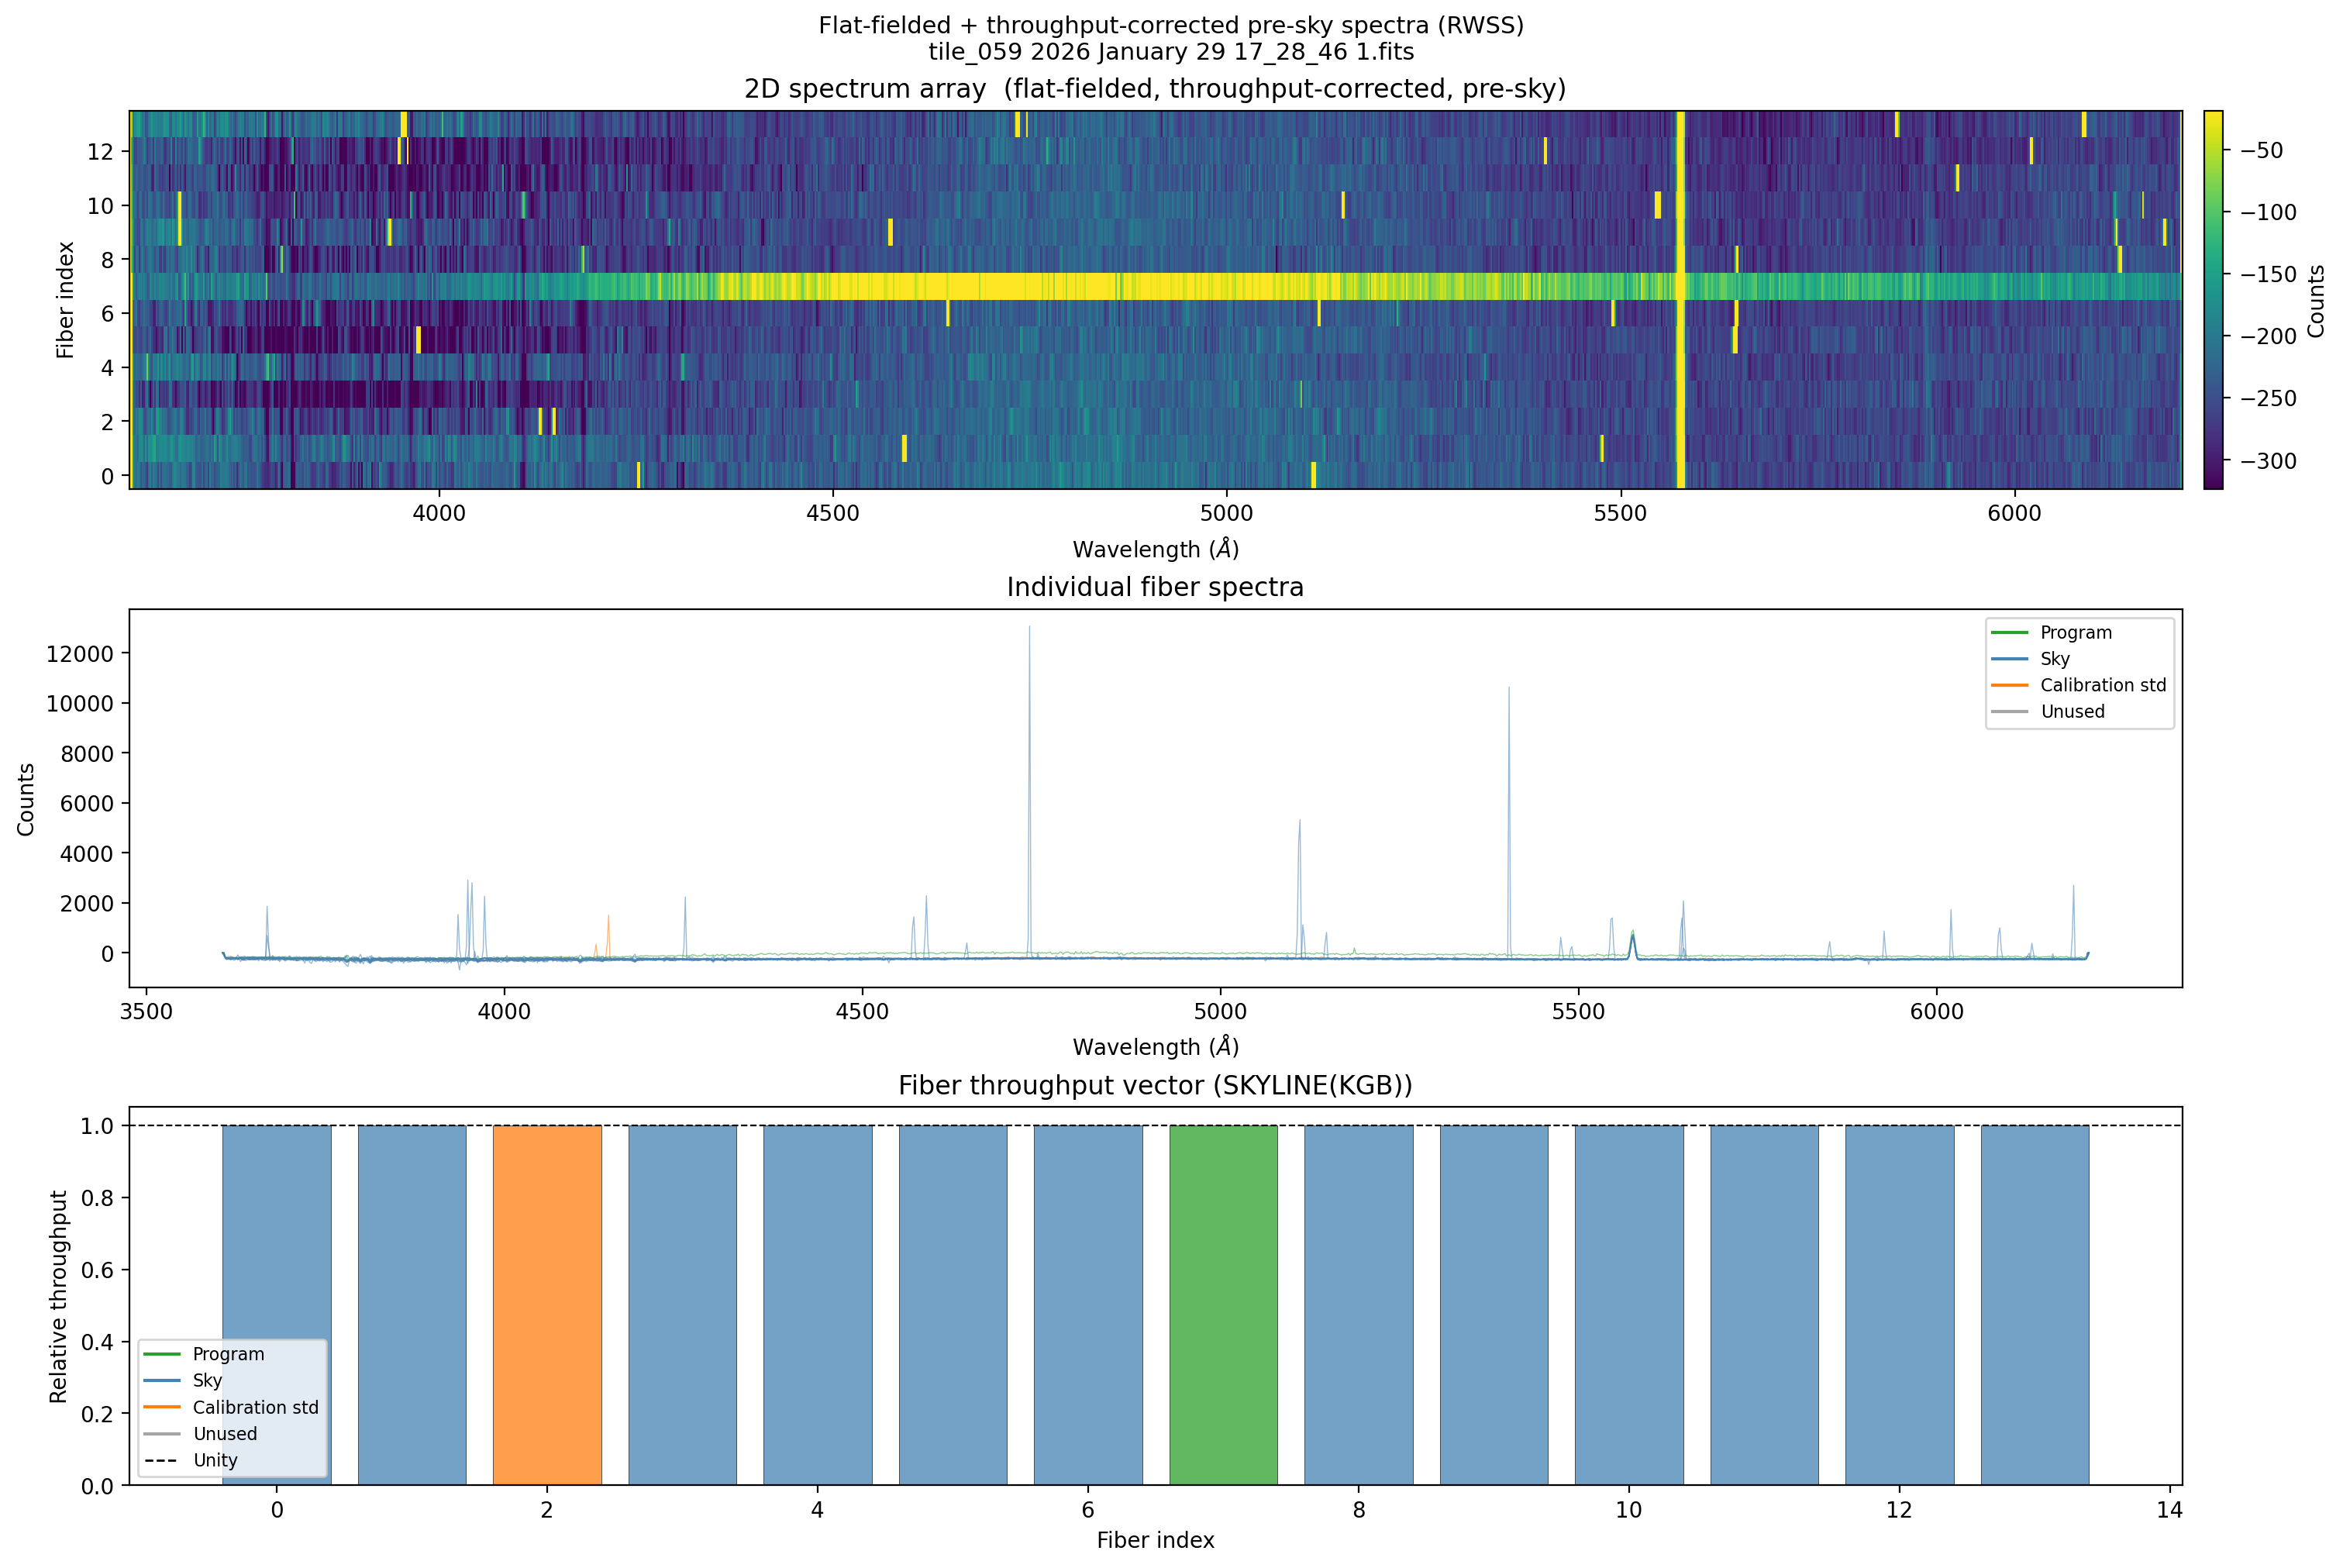

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Flat-fielded + throughput-corrected pre-sky spectra  (RWSS extension)
# RWSS = post flat-field, post scrunch, post SKYLINE(KGB) throughput, PRE sky-sub
# ─────────────────────────────────────────────────────────────────────────────
job = obj_jobs[0]

with fits.open(job["red"]) as hdul:
    hdul.info()
    wave_hdu  = hdul["WAVELA"].data if "WAVELA" in hdul else None
    rwss      = hdul["RWSS"].data.astype(float)
    thput_vec = hdul["THPUT"].data.astype(float) if "THPUT" in hdul else None

with ImageFile(job["red"].as_posix(), mode="READ") as red_f:
    fiber_types, _ = red_f.read_fiber_types(1000)

if wave_hdu is not None and wave_hdu.ndim == 2:
    wave = wave_hdu[0]
elif wave_hdu is not None:
    wave = wave_hdu
else:
    wave = np.arange(rwss.shape[1])

nfib  = rwss.shape[0]
ftypes = list(fiber_types[:nfib])

colors_by_type = {"S": "steelblue", "P": "tab:green", "C": "tab:orange", "N": "0.65"}
type_labels    = {"S": "Sky", "P": "Program", "C": "Calibration std", "N": "Unused"}
legend_handles = [
    Line2D([0], [0], color=colors_by_type[t], lw=1.5, label=type_labels[t])
    for t in ["P", "S", "C", "N"]
]

fig, axes = plt.subplots(3, 1, figsize=(15, 10), constrained_layout=True)
fig.suptitle(
    f"Flat-fielded + throughput-corrected pre-sky spectra (RWSS)\n{job['raw'].name}",
    fontsize=11,
)

# — 2D image —
ax = axes[0]
vmin, vmax = np.nanpercentile(rwss, [2, 98])
im_plot = ax.imshow(
    rwss, origin="lower", aspect="auto", cmap="viridis",
    vmin=vmin, vmax=vmax,
    extent=[wave[0], wave[-1], -0.5, nfib - 0.5],
    interpolation="none",
)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Fiber index")
ax.set_title("2D spectrum array  (flat-fielded, throughput-corrected, pre-sky)")
plt.colorbar(im_plot, ax=ax, label="Counts", fraction=0.015, pad=0.01)

# — Individual spectra colour-coded by fiber type —
ax = axes[1]
for i in range(nfib):
    ftype = ftypes[i] if i < len(ftypes) else "N"
    c     = colors_by_type.get(ftype, "0.65")
    valid = np.isfinite(rwss[i])
    if np.sum(valid) > 10:
        ax.plot(wave[valid], rwss[i][valid], lw=0.5, alpha=0.55, color=c)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Counts")
ax.set_title("Individual fiber spectra")
ax.legend(handles=legend_handles, fontsize=8, loc="upper right")

# — SKYLINE(KGB) throughput vector —
ax = axes[2]
if thput_vec is not None:
    for i in range(min(nfib, len(thput_vec))):
        ftype = ftypes[i] if i < len(ftypes) else "N"
        c = colors_by_type.get(ftype, "0.65")
        t_val = float(thput_vec[i])
        if np.isfinite(t_val) and t_val > 0:
            ax.bar(i, t_val, color=c, width=0.8, alpha=0.75, edgecolor="k", linewidth=0.3)
    ax.axhline(1.0, color="k", lw=0.8, ls="--", label="Unity")
    ax.set_xlabel("Fiber index")
    ax.set_ylabel("Relative throughput")
    ax.set_title("Fiber throughput vector (SKYLINE(KGB))")
    ax.legend(
        handles=legend_handles + [Line2D([0], [0], color="k", ls="--", lw=1, label="Unity")],
        fontsize=8,
    )
else:
    ax.text(0.5, 0.5, "THPUT extension not found", transform=ax.transAxes, ha="center")

plt.show()

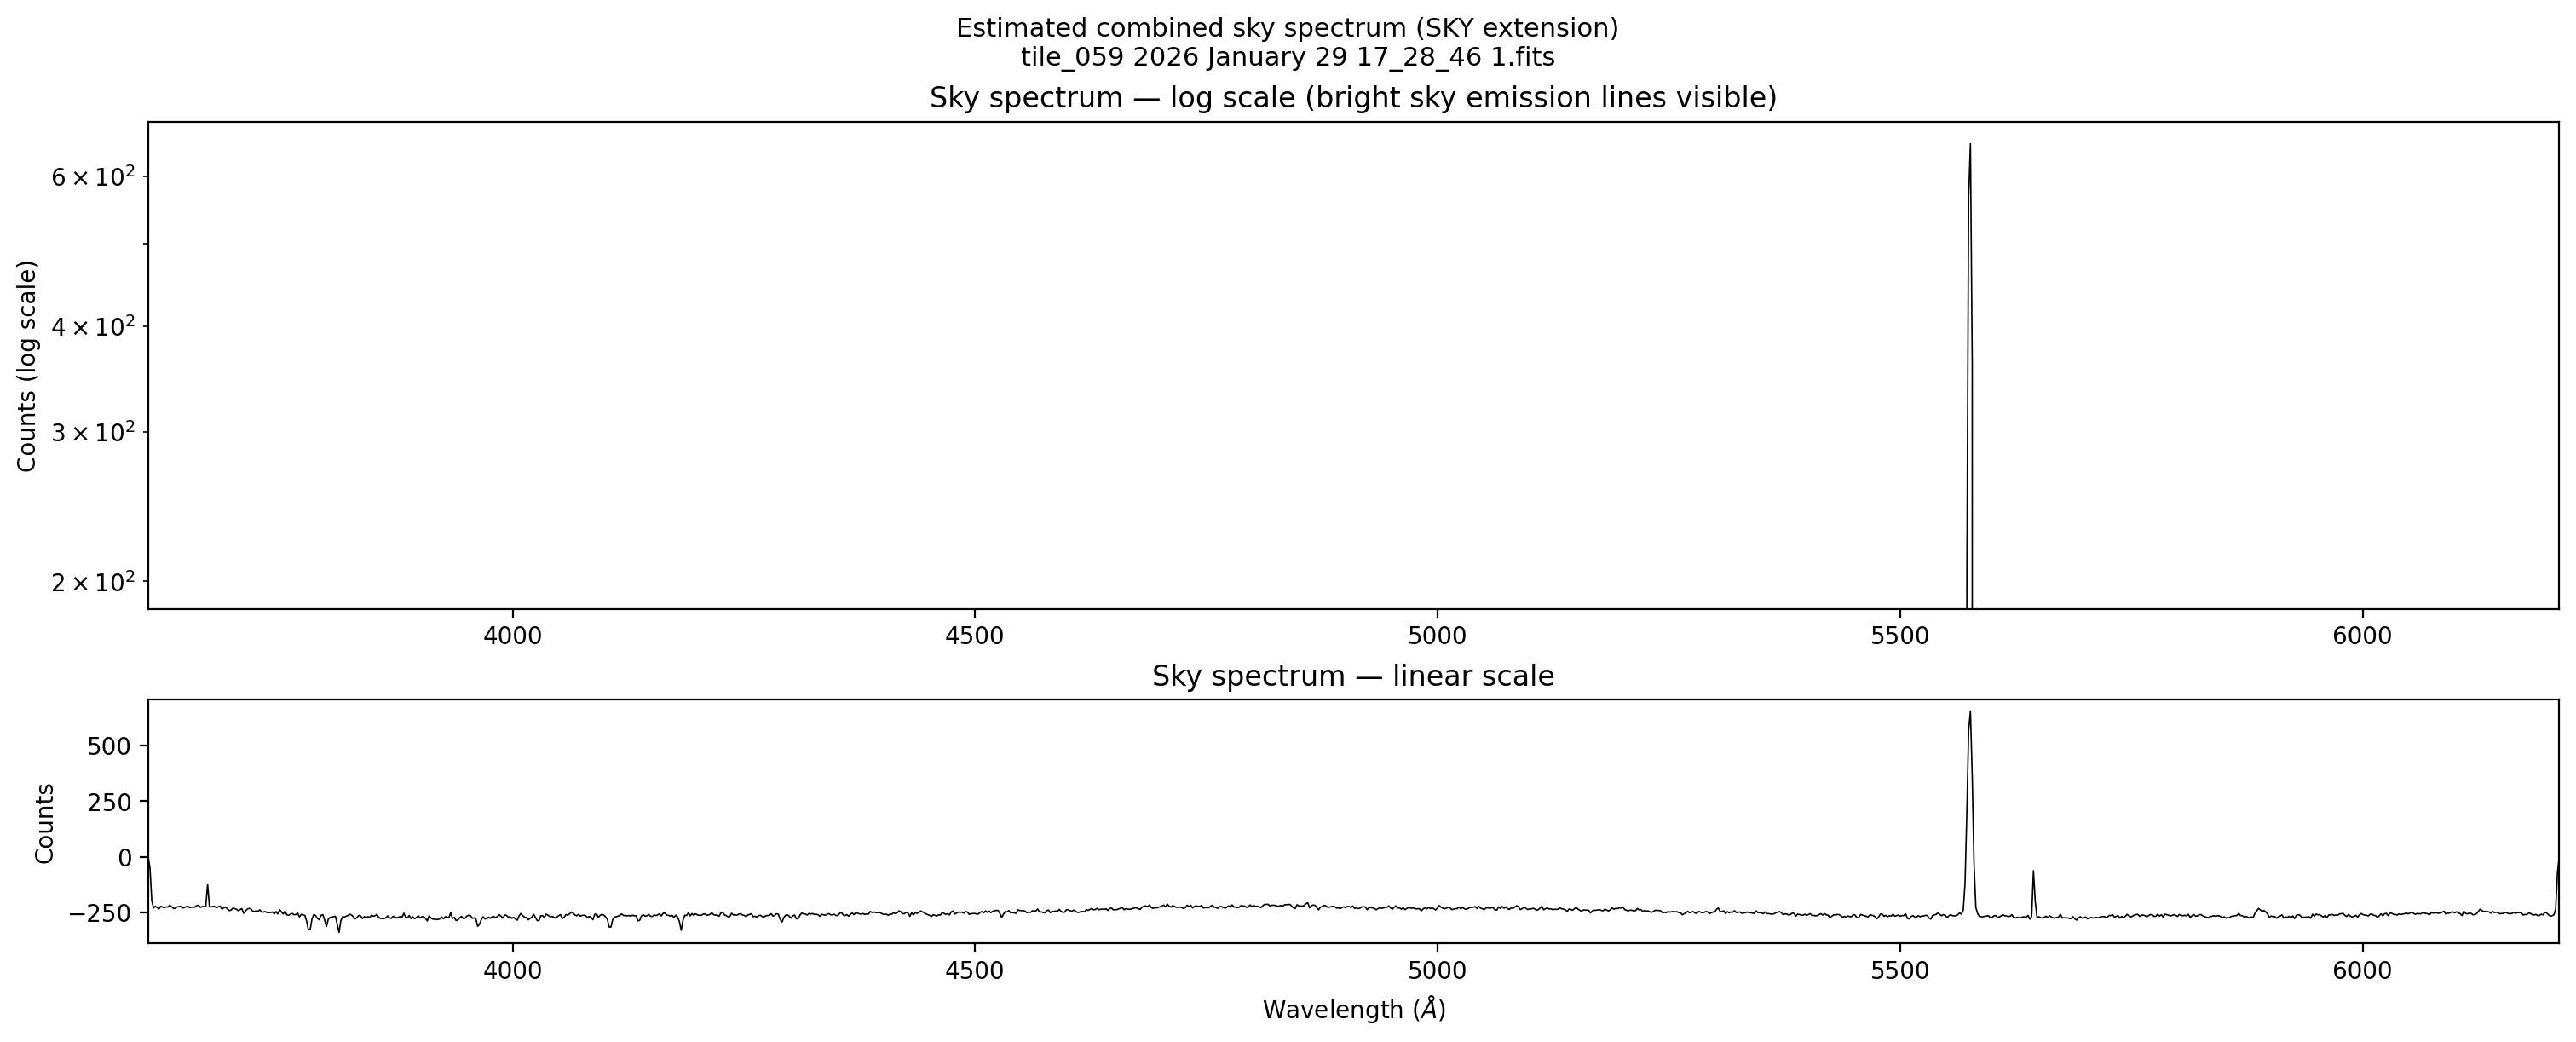

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# Estimated combined sky spectrum  (SKY extension)
# Combined from all sky fibers (TYPE='S') by mean combination
# ─────────────────────────────────────────────────────────────────────────────
job = obj_jobs[0]

with fits.open(job["red"]) as hdul:
    sky = hdul["SKY"].data.astype(float)

fig, axes = plt.subplots(2, 1, figsize=(15, 6), constrained_layout=True,
                         gridspec_kw={"height_ratios": [2, 1]})
fig.suptitle(f"Estimated combined sky spectrum (SKY extension)\n{job['raw'].name}", fontsize=11)

valid = np.isfinite(sky) #& (sky > 0)

ax = axes[0]
ax.plot(wave[valid], sky[valid], "k-", lw=0.6)
ax.set_ylabel("Counts (log scale)")
ax.set_title("Sky spectrum — log scale (bright sky emission lines visible)")
ax.set_yscale("log")
ax.set_xlim(wave[0], wave[-1])

ax = axes[1]
ax.plot(wave[valid], sky[valid], "k-", lw=0.6)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Counts")
ax.set_title("Sky spectrum — linear scale")
ax.set_xlim(wave[0], wave[-1])

plt.show()

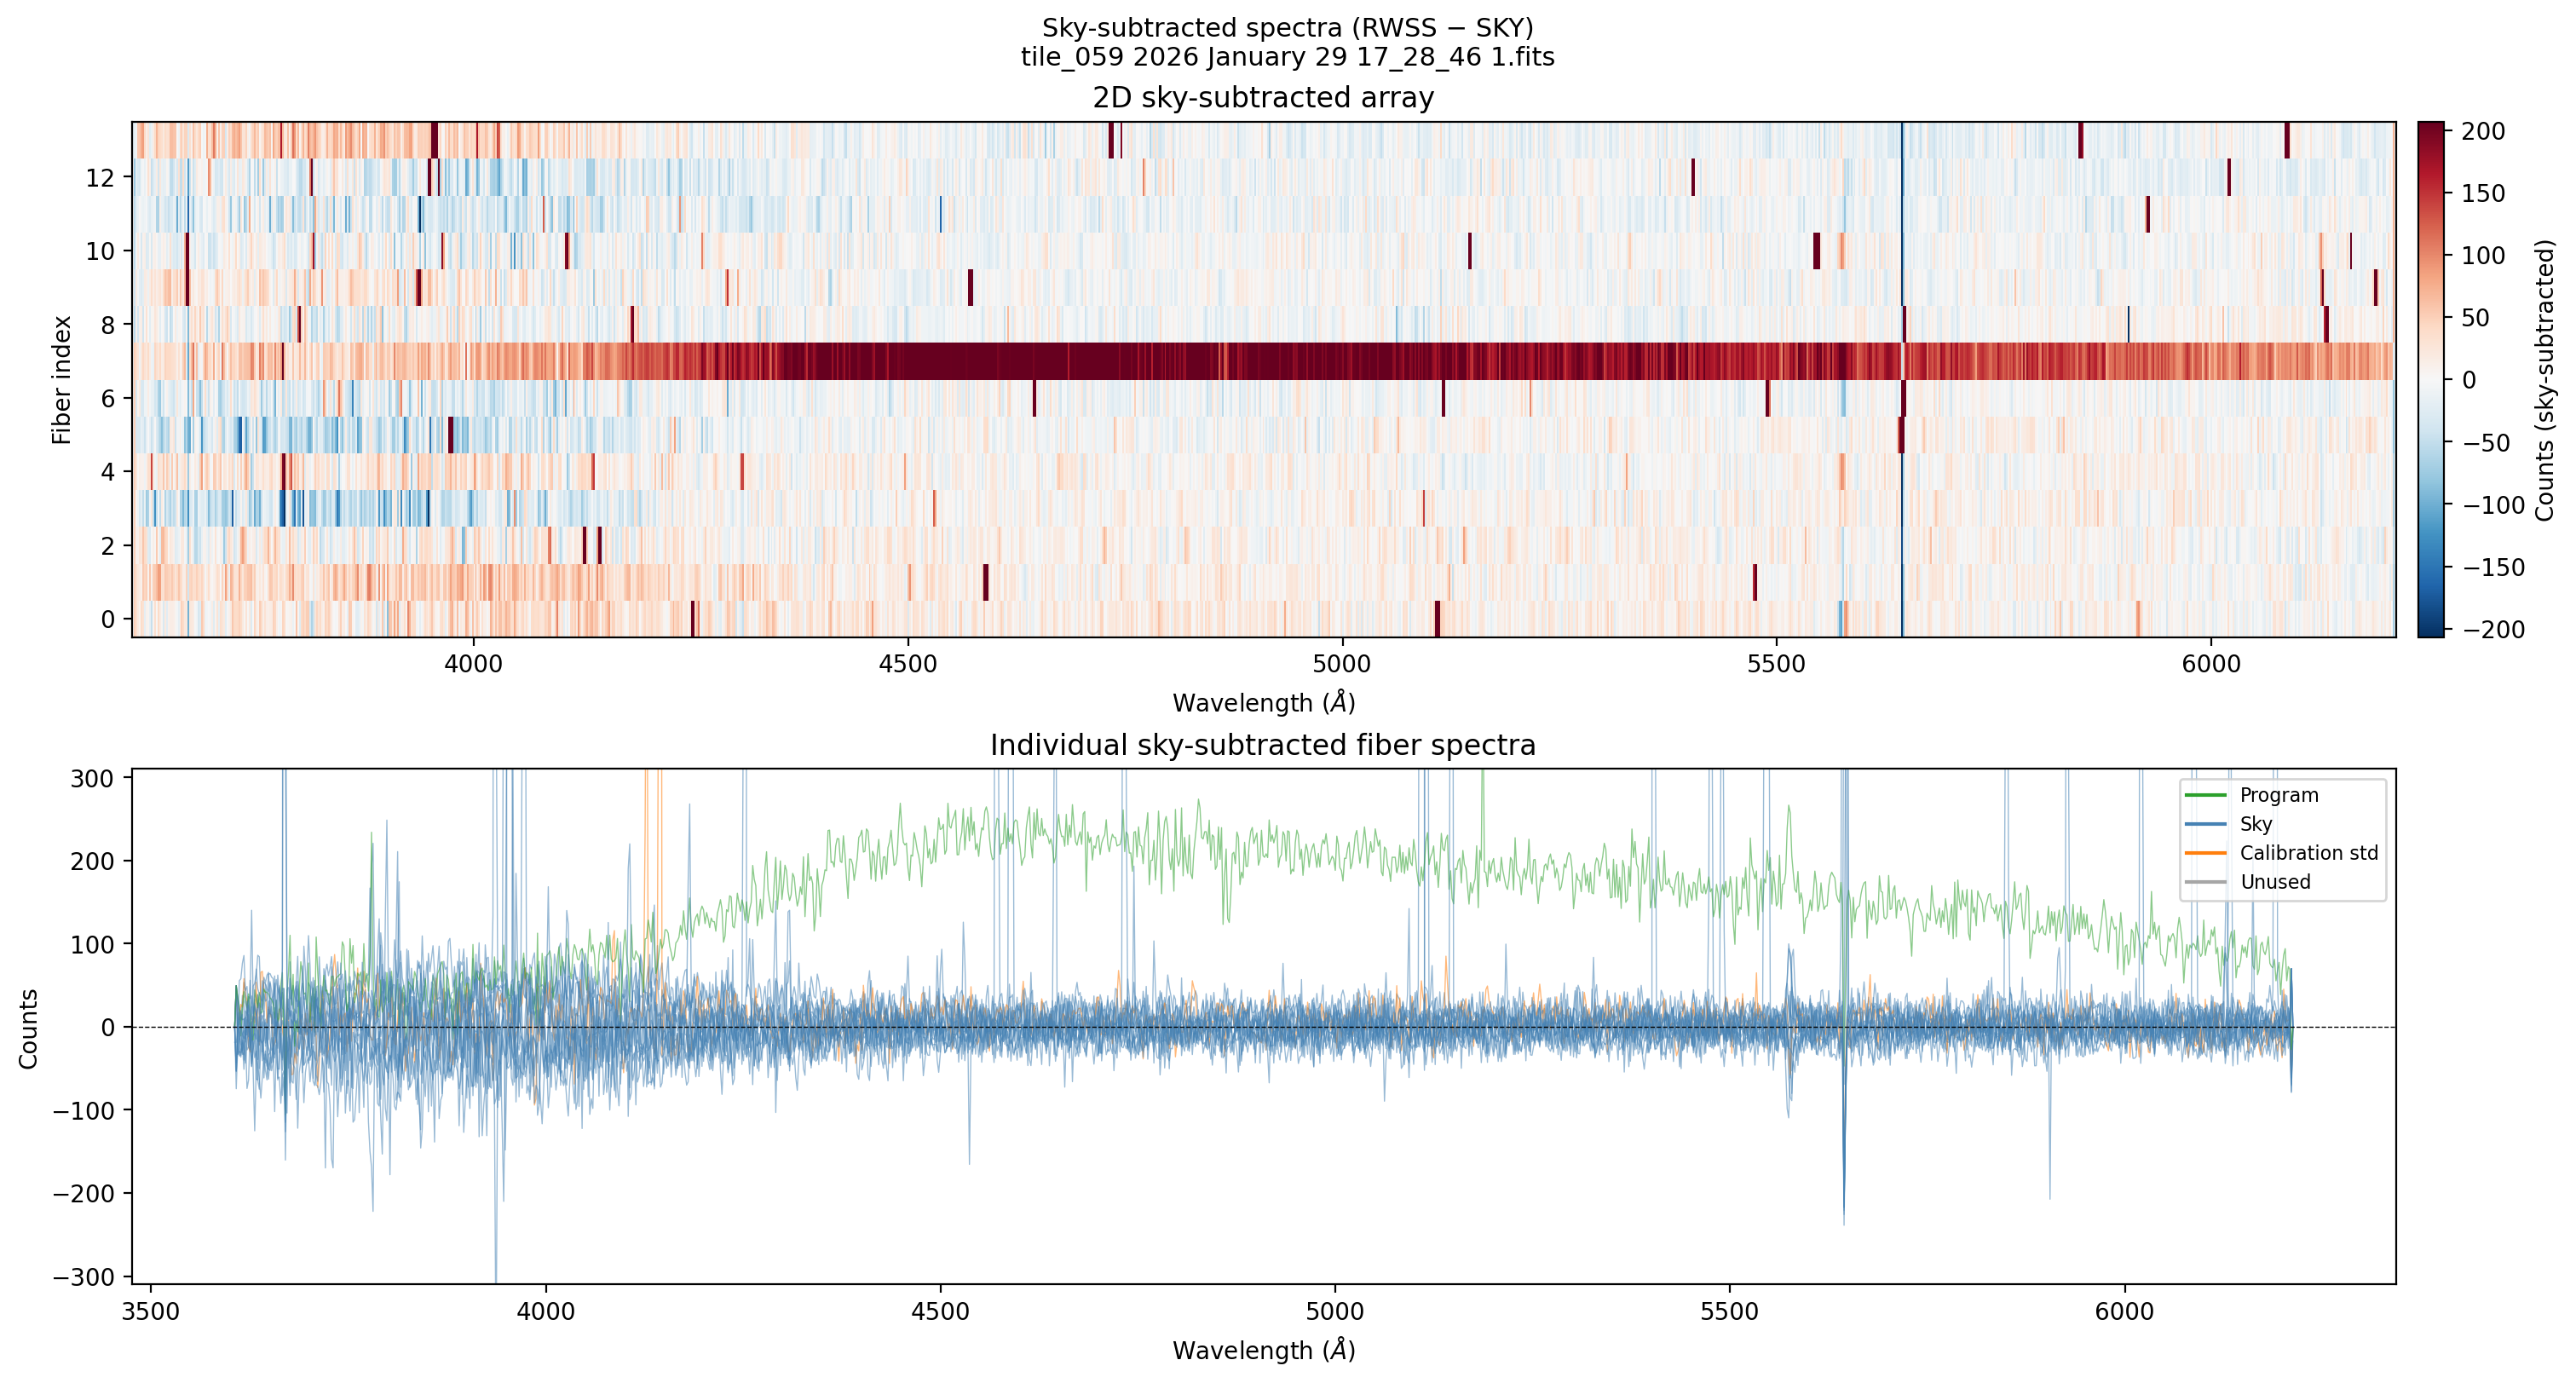

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# Sky-subtracted spectra  (RWSS − SKY, per fiber)
# ─────────────────────────────────────────────────────────────────────────────
job = obj_jobs[0]

with fits.open(job["red"]) as hdul:
    rwss_sk = hdul["RWSS"].data.astype(float)
    sky_sk  = hdul["SKY"].data.astype(float)

sky_sub = rwss_sk - sky_sk[np.newaxis, :]   # broadcast sky over all fibers

fig, axes = plt.subplots(2, 1, figsize=(15, 8), constrained_layout=True)
fig.suptitle(
    f"Sky-subtracted spectra (RWSS − SKY)\n{job['raw'].name}",
    fontsize=11,
)

# — 2D image (diverging colormap centred at zero) —
ax = axes[0]
clip_val = np.nanpercentile(np.abs(sky_sub), 98)
im_plot = ax.imshow(
    sky_sub, origin="lower", aspect="auto", cmap="RdBu_r",
    vmin=-clip_val, vmax=clip_val,
    extent=[wave[0], wave[-1], -0.5, nfib - 0.5],
    interpolation="none",
)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Fiber index")
ax.set_title("2D sky-subtracted array")
plt.colorbar(im_plot, ax=ax, label="Counts (sky-subtracted)", fraction=0.015, pad=0.01)

# — Individual spectra —
ax = axes[1]
for i in range(nfib):
    ftype = ftypes[i] if i < len(ftypes) else "N"
    c     = colors_by_type.get(ftype, "0.65")
    valid = np.isfinite(sky_sub[i])
    if np.sum(valid) > 10:
        ax.plot(wave[valid], sky_sub[i][valid], lw=0.5, alpha=0.55, color=c)
ax.axhline(0, color="k", lw=0.5, ls="--")
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Counts")
ax.set_title("Individual sky-subtracted fiber spectra")
ylim = np.nanpercentile(np.abs(sky_sub[np.isfinite(sky_sub)]), 98) * 1.5
ax.set_ylim(-ylim, ylim)
ax.legend(handles=legend_handles, fontsize=8, loc="upper right")

plt.show()

<>:113: SyntaxWarning: invalid escape sequence '\A'
<>:113: SyntaxWarning: invalid escape sequence '\A'
/var/folders/c3/0f663kw90xldstvklyr5nq9c0000gn/T/ipykernel_70952/2584451944.py:113: SyntaxWarning: invalid escape sequence '\A'
  r"$\bf{CENTWAVE}$: "+f"{hdr['LAMBDAC']} $\AA$" + \


Text(0, -0.5, '$\\bf{KSPEC \\ IsoPlane \\ Commissioning}$\n$\\bf{Instrumental \\ sky\\text{-}subtracted \\ spectrum}$\n$\\bf{Target}$: SMSS J103525.99-433156.0 (shyunc), $\\bf{RA}$:158.8582, $\\bf{Dec}$: -43.5323\n$\\bf{Tile}$: 059, $\\bf{DATE}$: UT 2026-01-29T17:48:54, $\\bf{EXPTIME}$: 1200.0 s\n$\\bf{GRATING}$: 300, $\\bf{CENTWAVE}$: 4900.0 $\\AA$\n$\\bf{SkyMapper \\ PSF \\ magnitudes}$: $u$=14.19, $v$=13.80, $g$=13.10, $r$=12.88, $i$=12.74, $z$=12.70')

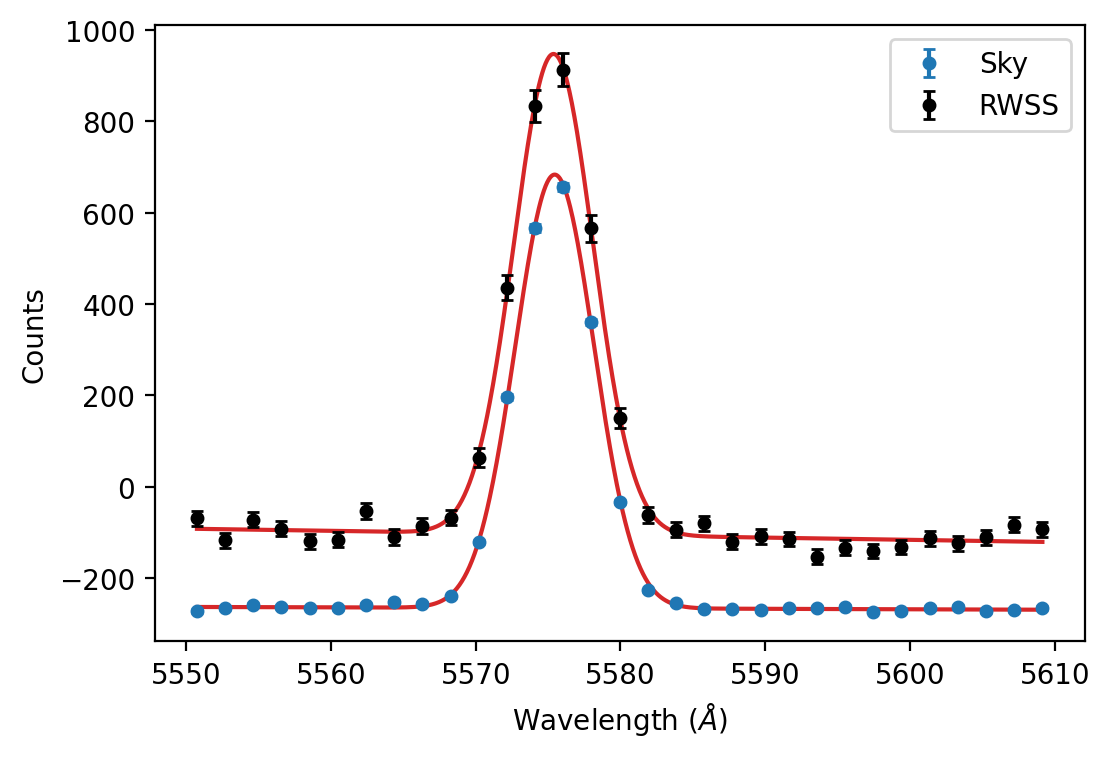

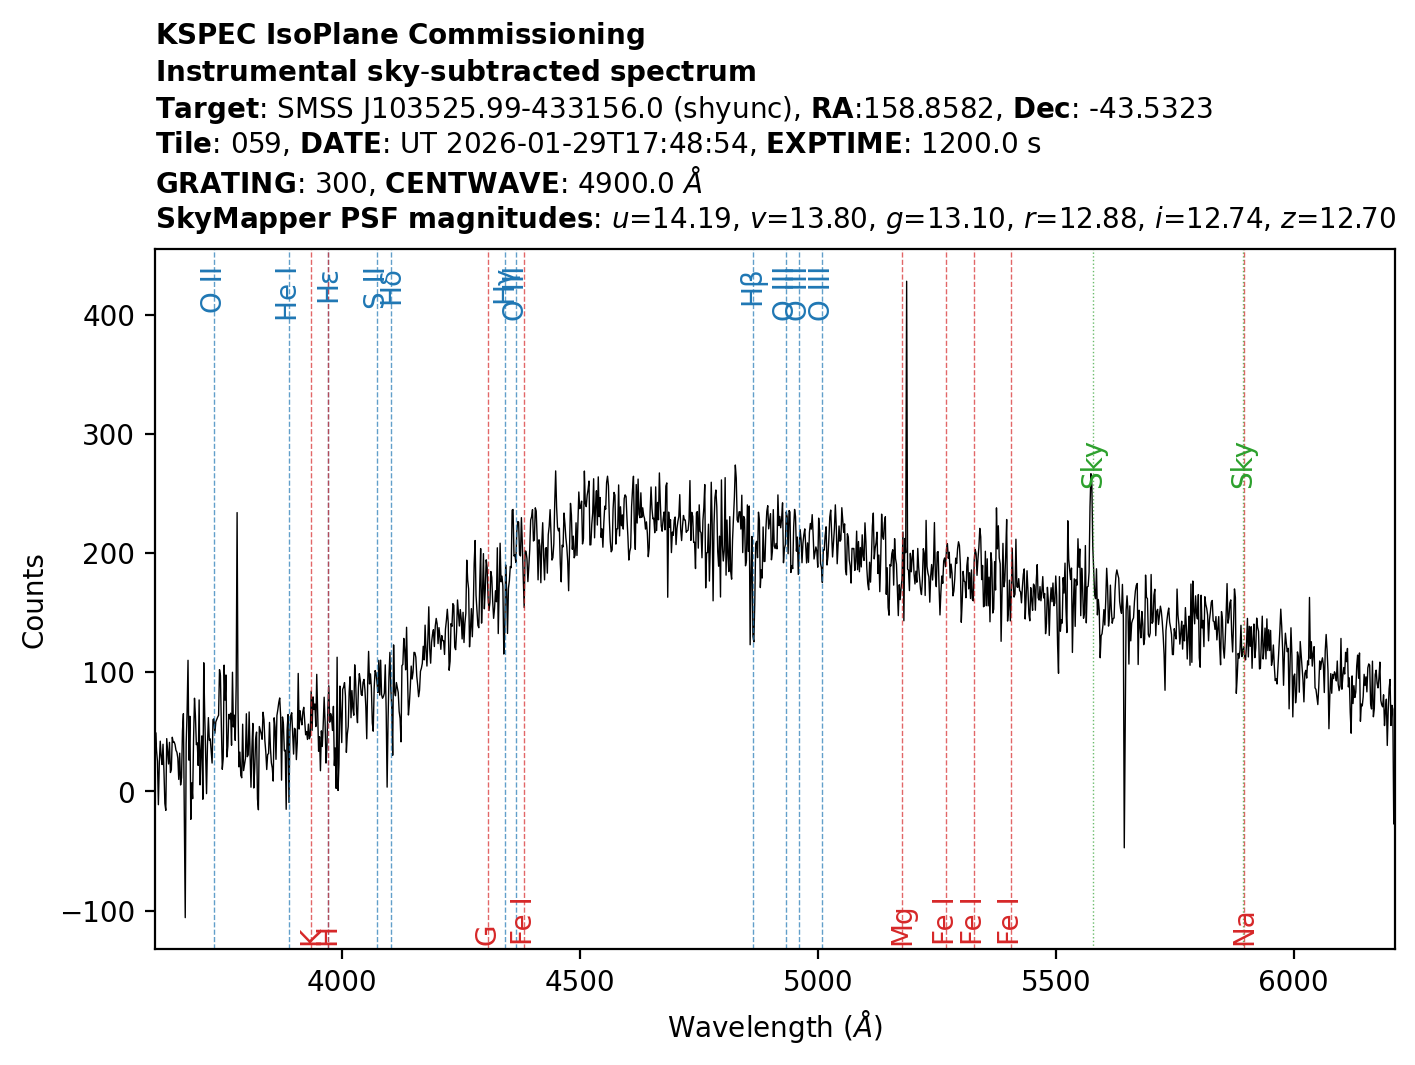

In [31]:
with fits.open(job["red"]) as hdul:
    rwss      = hdul["RWSS"].data.astype(float)
    rwss_sig  = np.sqrt(hdul["RWSSVAR"].data.astype(float))
    sky_sk    = hdul["SKY"].data.astype(float)
    sky_sk_sig = np.sqrt(hdul["SKYVAR"].data.astype(float))
    hdr = hdul[0].header

i = 7
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
valid = np.isfinite(sky_sub[i])

# gaussian + linear fit to the sky and rwss spectrum
from scipy.optimize import curve_fit
def gaussian_linear(x, a, b, c, d, e):
    return a * np.exp(-(x - b)**2 / (2 * c**2)) + d * x + e

skyline_window = np.where((wave > 5550) & (wave < 5610))[0]

popt_sky, _ = curve_fit(gaussian_linear, wave[skyline_window], sky_sk[skyline_window],
                        p0=[900, 5578, 5, 0, 300])
popt_rwss, _ = curve_fit(gaussian_linear, wave[skyline_window], rwss[i][skyline_window],
                        p0=[900, 5578, 5, 0, 100])

ww = np.linspace(wave[skyline_window][0], wave[skyline_window][-1], 1000)
ax.plot(ww, gaussian_linear(ww, *popt_sky), color="tab:red")
ax.plot(ww, gaussian_linear(ww, *popt_rwss), color="tab:red")
# ax.plot(wave[skyline_window], rwss[i][skyline_window], lw=0.8, color="k", marker="o", markersize=4, label="RWSS")
# ax.plot(wave[skyline_window], sky_sk[skyline_window], lw=0.8, color="tab:blue", marker="o", markersize=4, label="Sky")
ax.errorbar(wave[skyline_window], sky_sk[skyline_window], yerr=sky_sk_sig[skyline_window], color="tab:blue", alpha=1, label="Sky", ls="", marker="o", markersize=4, capsize=2)
ax.errorbar(wave[skyline_window], rwss[i][skyline_window], yerr=rwss_sig[i][skyline_window], color="k", alpha=1, label="RWSS", ls="", marker="o", markersize=4, capsize=2)
ax.legend()

ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Counts")


# running median in 5 pixels
from scipy.signal import medfilt
sky_sub_again = rwss[i] - sky_sk * popt_rwss[0] / popt_sky[0]

sky_sub_med = medfilt(sky_sub_again, kernel_size=5)

# 3-pixel binning
sky_sub_bin = np.median(sky_sub_again[2:].reshape(-1, 3), axis=1)
# wavelength midpoint
wave_bin = wave[2:].reshape(-1, 3).mean(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={"height_ratios": [1, 5]})
ax = axes[1]
ax.plot(wave[valid], sky_sub[i][valid], lw=0.5, color="k")
# ax.plot(wave, sky_sub_med, lw=0.5, color="k")
# ax.plot(wave, sky_sub_again, lw=0.5, color="k")
# ax.errorbar(wave, sky_sub_again, yerr=rwss_sig[i], color="k", alpha=1, label="RWSS", ls="", marker="o", markersize=1, elinewidth=0.5)
# ax.step(wave_bin, sky_sub_bin, lw=0.5, color="k", where="mid")
# ax.plot(wave_bin, sky_sub_bin, lw=0.5, color="k")
# ax.plot(wave, sky_sk, lw=0.5, color="k", alpha=0.5)
# ax.axhline(0, color="k", lw=0.5, ls="--")
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Counts")
# ax.set_title("Instrumental sky-subtracted spectrum")
# ylim = np.nanpercentile(np.abs(sky_sub[np.isfinite(sky_sub)]), 98) * 1.5
# ax.set_ylim(-ylim, ylim)

# ax.legend(handles=legend_handles, fontsize=8, loc="upper right")

emission_lines = [
    (3729.875, "O II"), (3889.0, "He I"), (3970.1, "Hε"), (4072.3, "S II"),
    (4102.89, "Hδ"), (4341.68, "Hγ"), (4364.436, "O III"),
    (4862.68, "Hβ"), (4932.603, "O III"), (4960.295, "O III"),
    (5008.240, "O III"), (6302.046, "O I"), (6365.536, "O I"),
    (6529.03, "N I"), (6549.86, "N II"), (6564.61, "Hα"),
    (6585.27, "N II"), (6718.29, "S II"), (6732.67, "S II"),
]
absorption_lines = [
    (3934.777, "K"), (3969.588, "H"), (4305.61, "G"),
    (5176.7, "Mg"), (5895.6, "Na"),
    (8500.36, "CaII"), (8544.44, "CaII"), (8664.52, "CaII"),
    (4383., "Fe I"), (5270., "Fe I"), (5328., "Fe I"), (5406., "Fe I"),
]
sky_lines = [
    (5578.5, "Sky"), (5894.6, "Sky"), (6301.7, "Sky"), (7246.0, "Sky"),
]
ax.set_xlim(wave[0], wave[-1])

ymin, ymax = ax.get_ylim()
for wave_l, name in emission_lines:
    if wave_l > wave[0] and wave_l < wave[-1]:
        ax.axvline(wave_l, color="tab:blue", lw=0.5, alpha=0.7, ls="--")
        ax.text(wave_l, ymax * 0.97, name, color="tab:blue",
                rotation=90, ha="center", va="top")

for wave_l, name in absorption_lines:
    if wave_l > wave[0] and wave_l < wave[-1]:
        ax.axvline(wave_l, color="tab:red", lw=0.5, alpha=0.7, ls="--")
        ax.text(wave_l, ymin * 0.97, name, color="tab:red",
                rotation=90, ha="center", va="bottom")

for wave_l, name in sky_lines:
    if wave_l > wave[0] and wave_l < wave[-1]:
        ax.axvline(wave_l, color="tab:green", lw=0.5, alpha=0.7, ls=":")
        ax.text(wave_l, ymax * 0.65, name, color="tab:green",
                rotation=90, ha="center", va="top")
    
axes[0].axis("off")
infotext = r"$\bf{KSPEC \ IsoPlane \ Commissioning}$" + \
    "\n" + r"$\bf{Instrumental \ sky\text{-}subtracted \ spectrum}$" + \
    "\n" + r"$\bf{Target}$: SMSS J103525.99-433156.0 (shyunc), " + \
    r"$\bf{RA}$:158.8582, $\bf{Dec}$: -43.5323" + \
    "\n" + r"$\bf{Tile}$: 059, $\bf{DATE}$: UT "+f"{hdr['DATE']}, " + \
    r"$\bf{EXPTIME}$: "+rf"{hdr['EXPOSED']} s" + \
    "\n" + r"$\bf{GRATING}$: "+f"{hdr['GRATID']}, " + \
    r"$\bf{CENTWAVE}$: "+f"{hdr['LAMBDAC']} $\AA$" + \
    "\n" + r"$\bf{SkyMapper \ PSF \ magnitudes}$: $u$=14.19, $v$=13.80, $g$=13.10, $r$=12.88, $i$=12.74, $z$=12.70"
axes[0].text(0, -0.5, infotext, ha="left", va="bottom", transform=axes[0].transAxes)
# axes[0].text

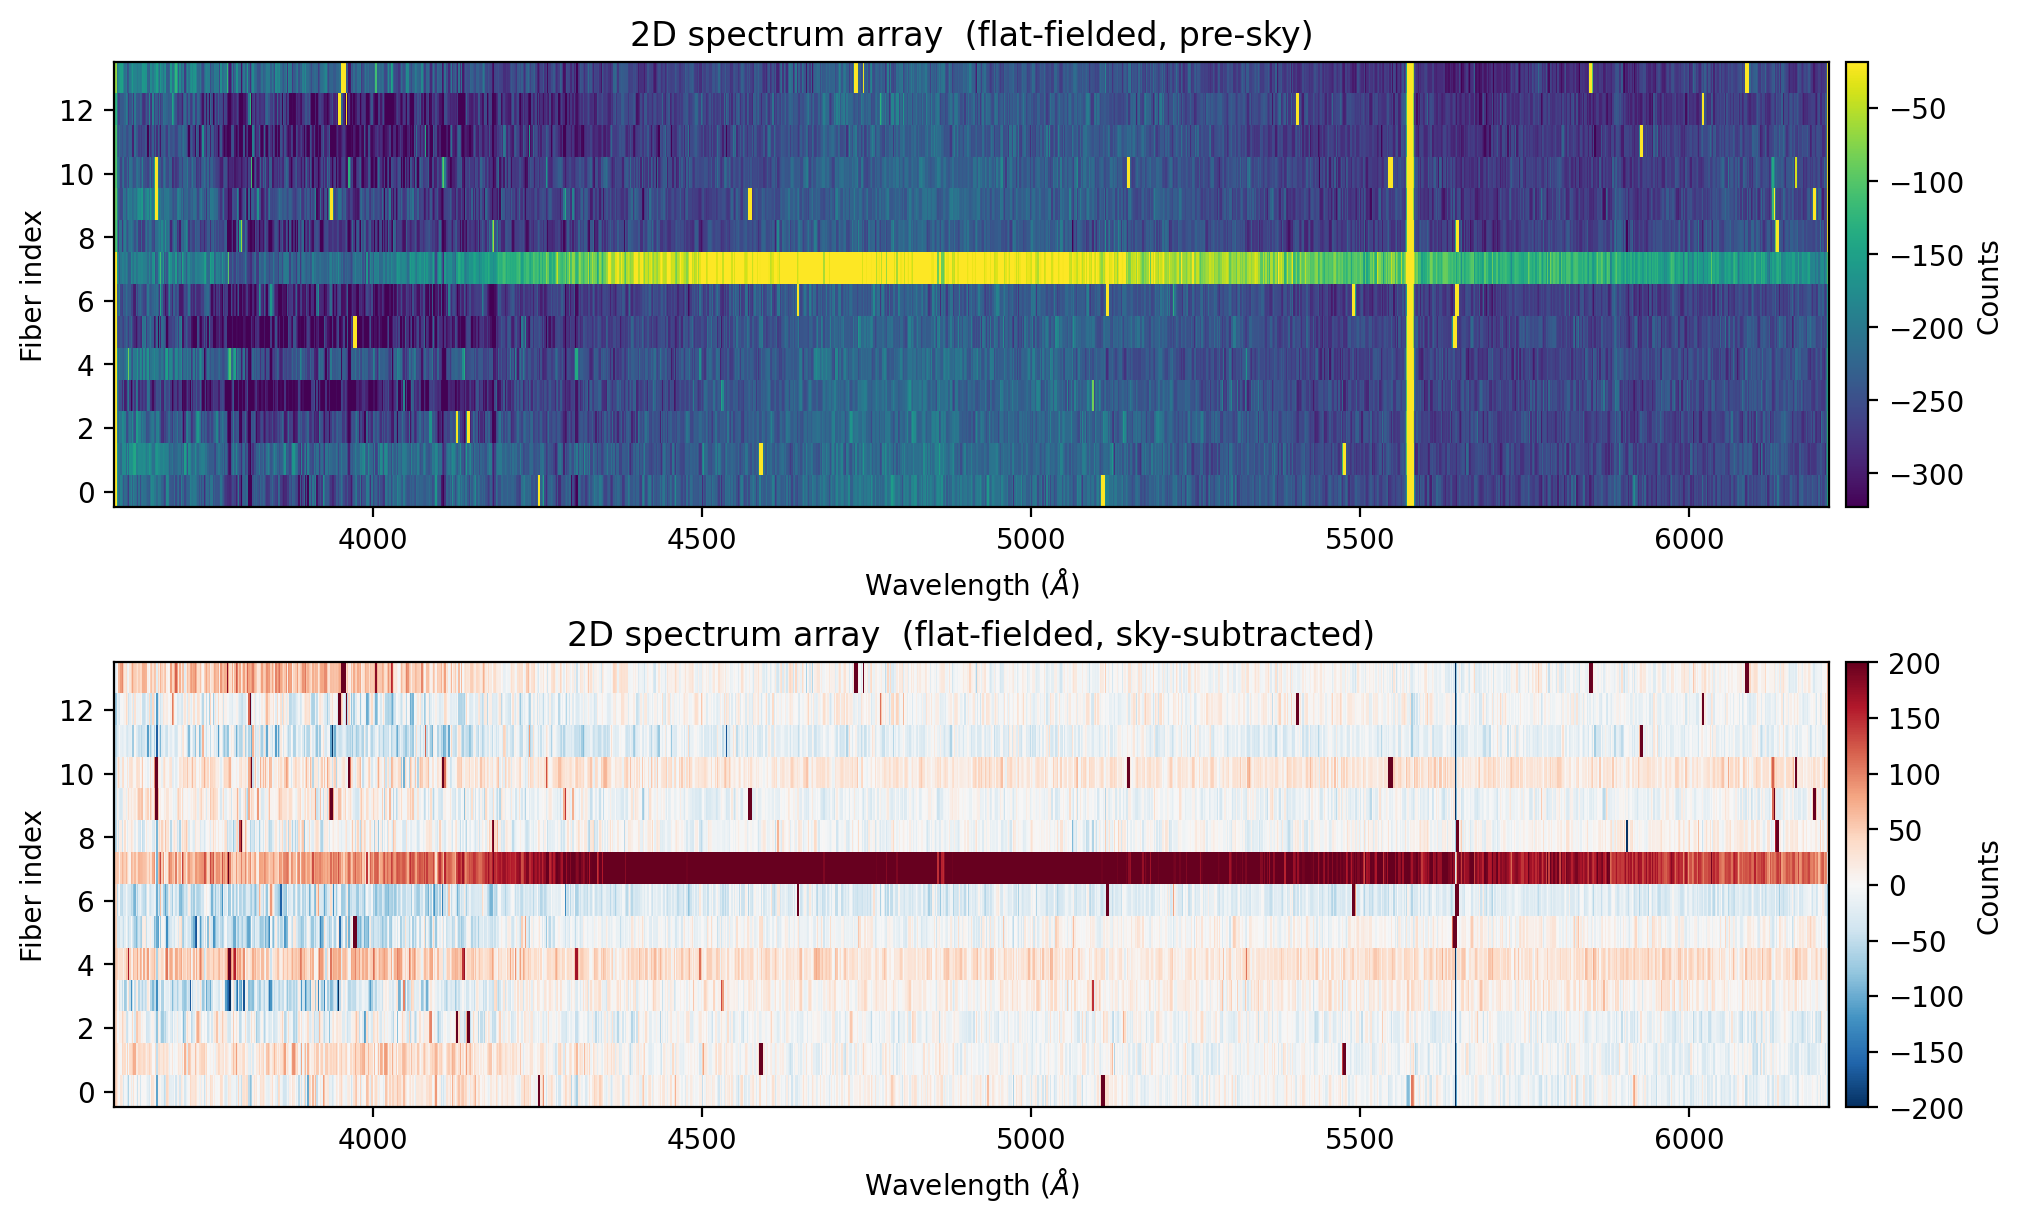

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)
ax = axes[0]
vmin, vmax = np.nanpercentile(rwss, [2, 98])
im_plot = ax.imshow(
    rwss, origin="lower", aspect="auto", cmap="viridis",
    vmin=vmin, vmax=vmax,
    extent=[wave[0], wave[-1], -0.5, nfib - 0.5],
    interpolation="none",
)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Fiber index")
ax.set_title("2D spectrum array  (flat-fielded, pre-sky)")
plt.colorbar(im_plot, ax=ax, label="Counts", fraction=0.015, pad=0.01)

rwss_sksub = np.zeros_like(rwss)
for i in range(nfib):
    valid = np.isfinite(rwss[i])

    popt_sky, _ = curve_fit(gaussian_linear, wave[skyline_window], sky_sk[skyline_window],
                            p0=[900, 5578, 5, 0, 300])
    popt_rwss, _ = curve_fit(gaussian_linear, wave[skyline_window], rwss[i][skyline_window],
                            p0=[900, 5578, 5, 0, 100])
    
    rwss_sksub[i] = rwss[i] - sky_sk * popt_rwss[0] / popt_sky[0]

ax = axes[1]
vmin, vmax = -200, 200
im_plot = ax.imshow(
    rwss_sksub, origin="lower", aspect="auto", cmap="RdBu_r",
    vmin=vmin, vmax=vmax,
    extent=[wave[0], wave[-1], -0.5, nfib - 0.5],
    interpolation="none",
)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Fiber index")
ax.set_title("2D spectrum array  (flat-fielded, sky-subtracted)")
plt.colorbar(im_plot, ax=ax, label="Counts", fraction=0.015, pad=0.01)
    
    

# Below is not useful since the standard star is not properly aligned

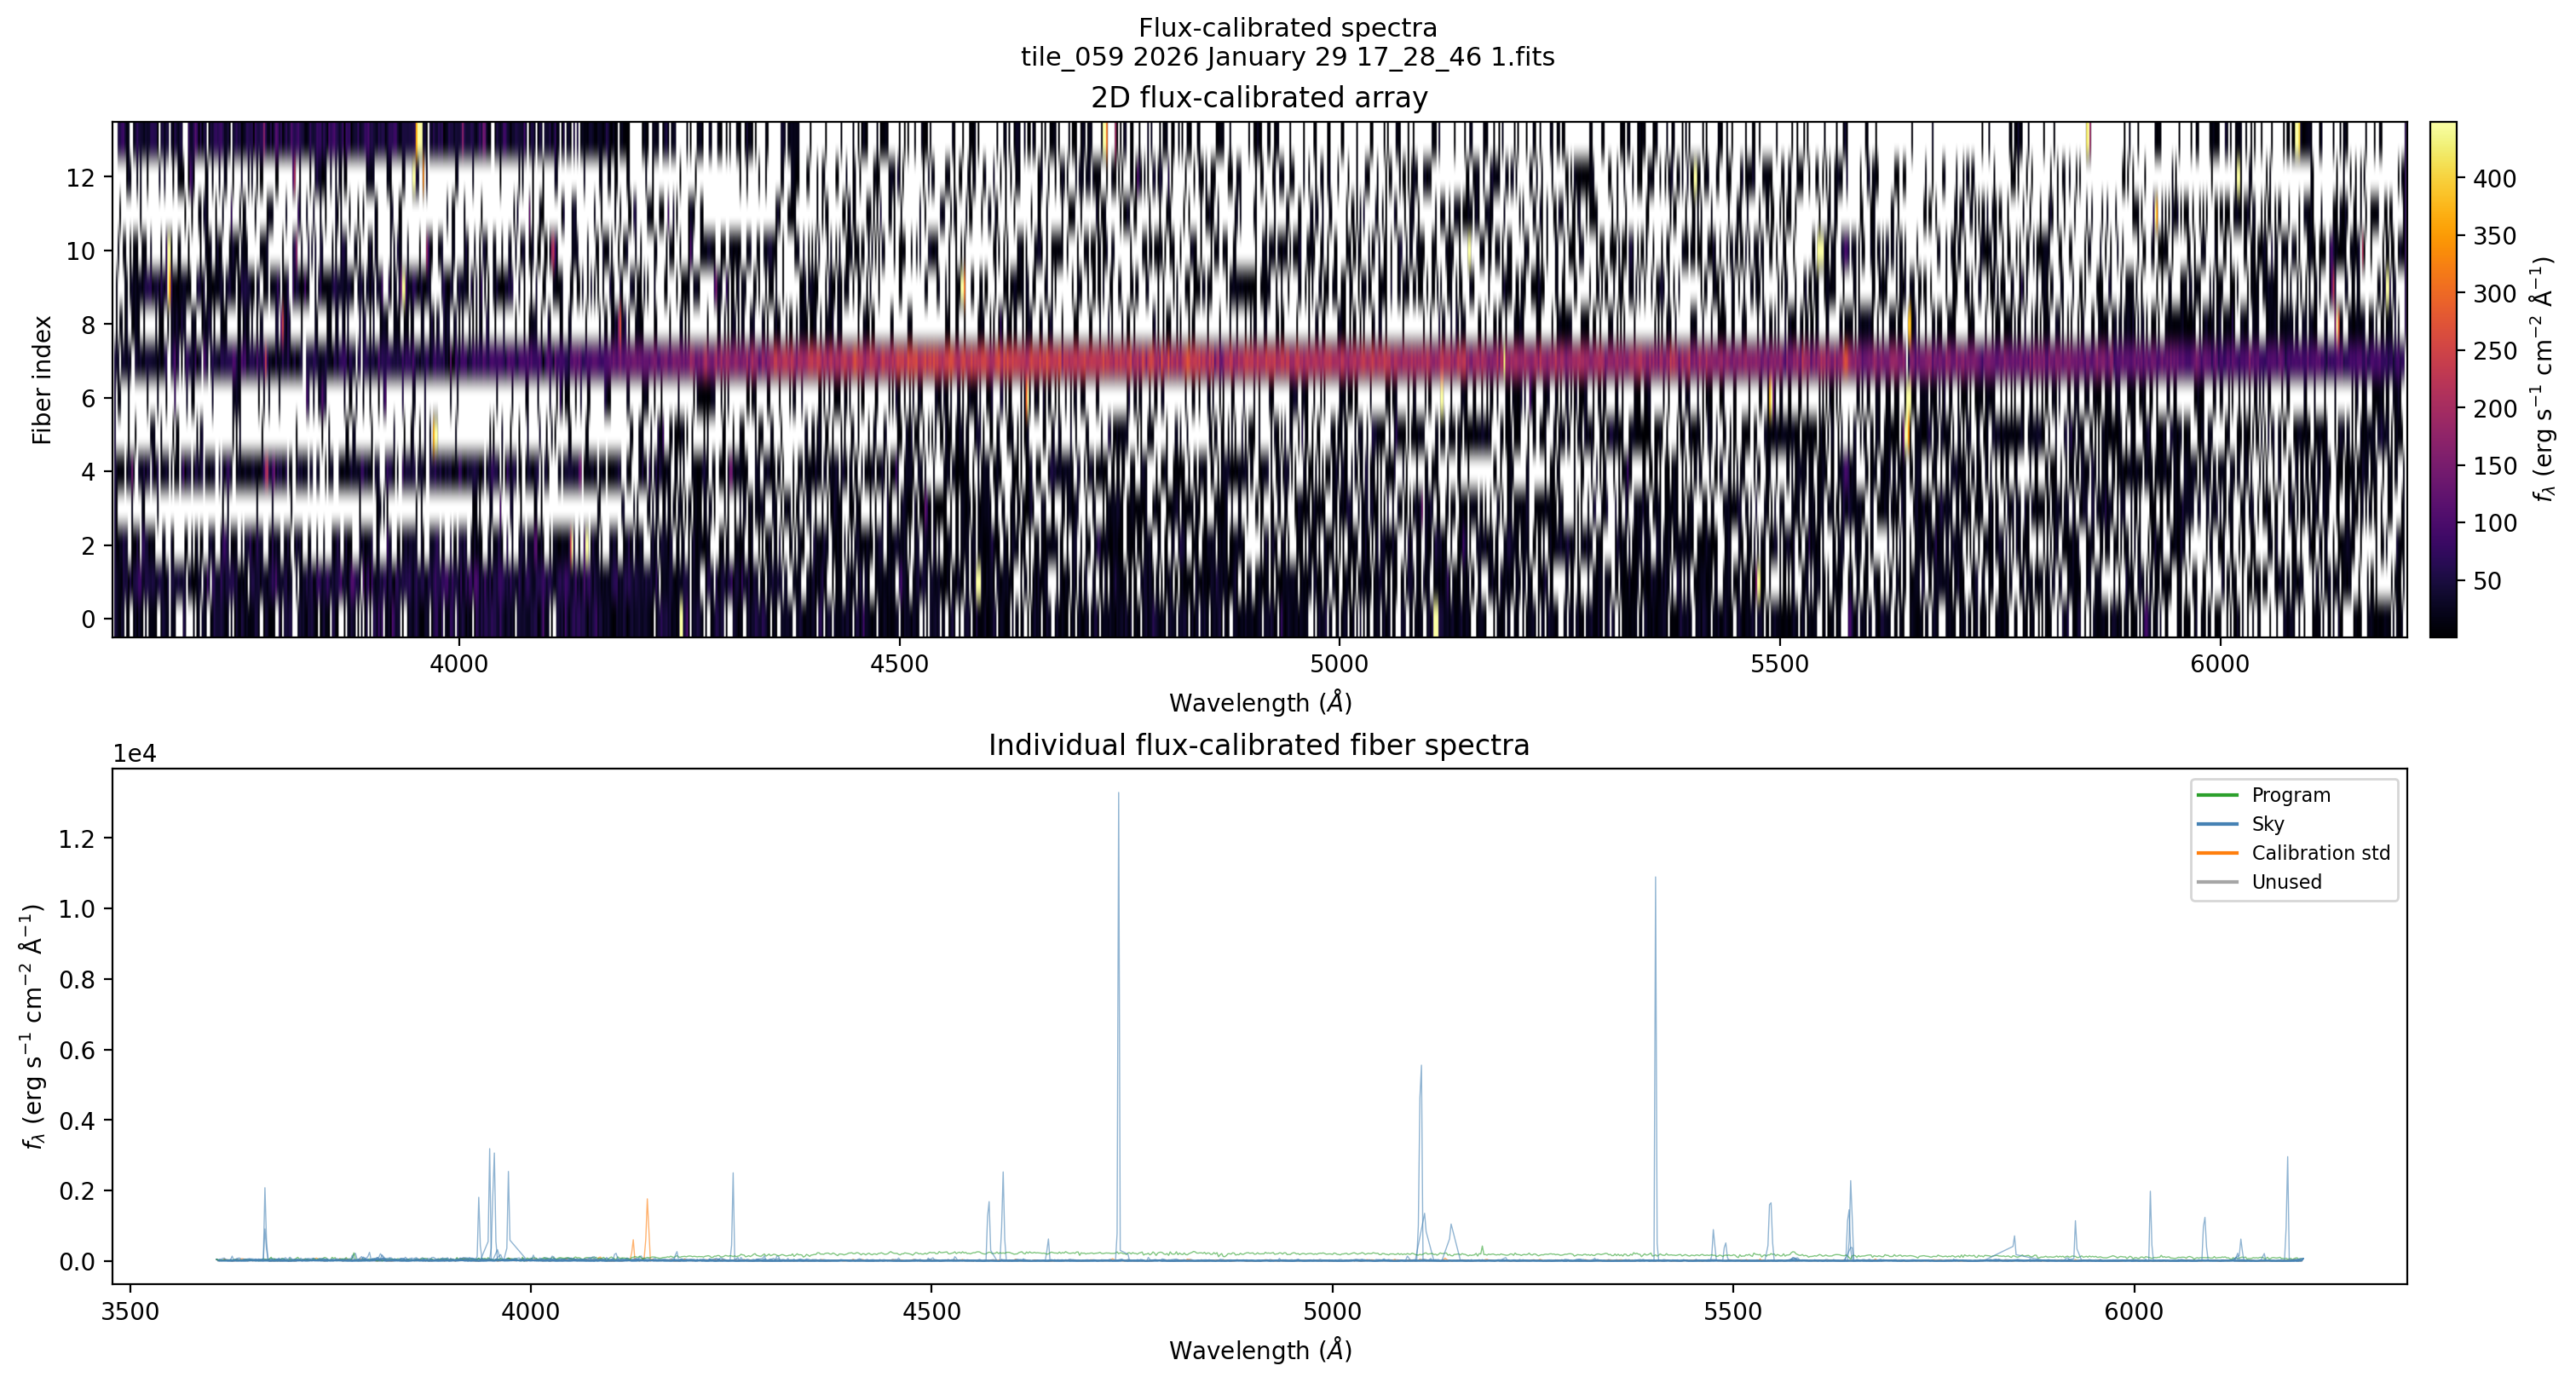

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Flux-calibrated spectra  (primary IMAGE HDU of the RED file)
# Units: erg s⁻¹ cm⁻² Å⁻¹
# ─────────────────────────────────────────────────────────────────────────────
job = obj_jobs[0]

with fits.open(job["red"]) as hdul:
    flux_cal = hdul[0].data.astype(float)

nfib_fc = flux_cal.shape[0]

fig, axes = plt.subplots(2, 1, figsize=(15, 8), constrained_layout=True)
fig.suptitle(f"Flux-calibrated spectra\n{job['raw'].name}", fontsize=11)

# — 2D image —
ax = axes[0]
finite_vals = flux_cal[np.isfinite(flux_cal) & (flux_cal > 0)]
if len(finite_vals) > 0:
    vmin_fc, vmax_fc = np.percentile(finite_vals, [1, 99.5])
else:
    vmin_fc, vmax_fc = 0, 1
im_plot = ax.imshow(
    np.where(flux_cal > 0, flux_cal, np.nan),
    origin="lower", aspect="auto", cmap="inferno",
    vmin=vmin_fc, vmax=vmax_fc,
    extent=[wave[0], wave[-1], -0.5, nfib_fc - 0.5],
)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Fiber index")
ax.set_title("2D flux-calibrated array")
plt.colorbar(
    im_plot, ax=ax,
    label=r"$f_\lambda$ (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)",
    fraction=0.015, pad=0.01,
)

# — Individual spectra —
ax = axes[1]
for i in range(min(nfib_fc, nfib)):
    ftype = ftypes[i] if i < len(ftypes) else "N"
    c     = colors_by_type.get(ftype, "0.65")
    valid = np.isfinite(flux_cal[i]) & (flux_cal[i] > 0)
    if np.sum(valid) > 10:
        ax.plot(wave[valid], flux_cal[i][valid], lw=0.5, alpha=0.6, color=c)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel(r"$f_\lambda$ (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
ax.set_title("Individual flux-calibrated fiber spectra")
ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))
ax.legend(handles=legend_handles, fontsize=8, loc="upper right")

plt.show()

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Flux calibration procedure diagnostics
# Re-run the per-star calibration step outside reduce_object to capture
# CalibrationVector objects for QC plotting.
# Input:  sky-subtracted spectra reconstructed as RWSS − SKY
# ─────────────────────────────────────────────────────────────────────────────
job = obj_jobs[0]

with fits.open(job["red"]) as hdul:
    rwss_diag = hdul["RWSS"].data.astype(float)
    sky_diag  = hdul["SKY"].data.astype(float)

sky_sub_diag = rwss_diag - sky_diag[np.newaxis, :]

with ImageFile(job["red"].as_posix(), mode="READ") as red_f:
    wave_diag      = red_f.read_wave_data()
    ftypes_diag, _ = red_f.read_fiber_types(1000)

if wave_diag is not None and wave_diag.ndim == 2:
    wave_diag = wave_diag[0]
elif wave_diag is None:
    wave_diag = np.arange(sky_sub_diag.shape[1])

nfib_diag   = sky_sub_diag.shape[0]
ftypes_list = list(ftypes_diag[:nfib_diag])

# Calibration (TYPE='C') fiber indices
std_indices = [
    i for i in range(nfib_diag)
    if i < len(ftypes_list) and ftypes_list[i] == FIBER_TYPE_CALIBRATION
]
print(f"Calibration fiber indices (TYPE='{FIBER_TYPE_CALIBRATION}'): {std_indices}")

# Load fiber names from FIBRES table
fiber_names = {i: f"FIB{i}" for i in range(nfib_diag)}
try:
    with fits.open(job["red"]) as hdul:
        if "FIBRES" in hdul:
            fib_tbl = Table(hdul["FIBRES"].data)
            for i in range(min(nfib_diag, len(fib_tbl))):
                fiber_names[i] = str(fib_tbl["NAME"][i]).strip()
except Exception as exc:
    print(f"Could not read FIBRES table: {exc}")

# Load calibration resources
catalog_diag      = load_standard_star_catalog(CATALOG.as_posix())
library_diag      = TemplateLibrary()
filter_curves_diag = load_filter_curves(DEFAULT_BANDS)
mask_regions_diag = load_mask_regions("telluric_default")
instrument_fwhm   = 3.0   # Å — fallback; ideally read from SPECFWHM header

print(f"Catalog has {len(catalog_diag)} standard star(s)")

# ── Per-star calibration vectors ──
cal_vectors_diag = []
obs_specs_diag   = {}   # keep for later template-match plotting

for cat_idx, fib_idx in enumerate(std_indices):
    obs_flux = sky_sub_diag[fib_idx, :]
    obs_var  = np.where(obs_flux > 0, obs_flux, 1.0)   # Poisson approximation
    obs_mask = np.isfinite(obs_flux) & np.isfinite(obs_var)

    obs_spec = Spectrum1D(
        wavelength=wave_diag.copy(),
        flux=obs_flux.copy(),
        variance=obs_var.copy(),
        mask=obs_mask,
        meta={"fiber_id": fib_idx},
    )
    obs_specs_diag[fib_idx] = obs_spec

    star_name = fiber_names.get(fib_idx, f"FIB{fib_idx}")

    if cat_idx >= len(catalog_diag):
        print(f"Skipping fiber {fib_idx}: catalog has only {len(catalog_diag)} row(s)")
        continue

    row  = catalog_diag[cat_idx]
    phot = photometry_from_catalog_row(row)
    print(f"\nFiber {fib_idx} ({star_name})  Gaia G = {row['Gaia']:.2f} mag")

    try:
        cv = compute_calibration_vector_for_star(
            obs_spec, phot, library_diag, filter_curves_diag,
            instrument_fwhm_angstrom=instrument_fwhm,
            mask_regions=mask_regions_diag,
            metric="chi2",
            star_name=star_name,
            fiber_id=fib_idx,
        )
        cal_vectors_diag.append(cv)
    except Exception as exc:
        print(f"  ✗ Calibration failed: {exc}")

result_diag = None
if cal_vectors_diag:
    result_diag = combine_calibration_vectors(
        cal_vectors_diag, method="weighted_mean", smooth=False,
    )
    print("\n")
    print(summarize_calibration(result_diag))
else:
    print("No calibration vectors computed.")

2026-02-26 23:28:44,525 | kspecdr.fluxcal.templates | INFO | TemplateLibrary: 520 templates, wave 3000–11000 Å (30163 pixels)
2026-02-26 23:28:44,533 | kspecdr.fluxcal.matching | INFO | Template matching: 200 candidates in Teff=[5193, 6393]


Calibration fiber indices (TYPE='C'): [2]
Catalog has 1 standard star(s)

Fiber 2 (FIB3)  Gaia G = 13.28 mag


2026-02-26 23:28:59,060 | kspecdr.fluxcal.matching | INFO | Best template: Teff=5250 logg=5.0 [M/H]=+0.50 [α/M]=+0.00 (score=230.85, RV=432.6 km/s, 200 candidates)


  ✗ Calibration failed: module 'numpy' has no attribute 'trapz'
No calibration vectors computed.


In [27]:
if result_diag is None:
    print("No calibration result available — run the previous cell first.")
else:
    # ── 1. Four-panel calibration summary ──
    fig = plot_calibration_summary(result_diag, title="Flux Calibration Summary — tile_059")
    plt.show()

    # ── 2. Per-star calibration vectors with ±1σ band ──
    fig = plot_per_star_vectors(result_diag)
    plt.show()

    # ── 3. Per-band photometric residuals (synth − obs, mag) ──
    fig = plot_photometric_residuals(cal_vectors_diag)
    plt.show()

    # ── 4. Template match + calibration vector per standard star ──
    for cv in cal_vectors_diag:
        fib_idx   = cv.meta["fiber_id"]
        star_name = cv.meta.get("star_name", f"FIB{fib_idx}")
        teff      = cv.meta["teff"]
        logg      = cv.meta["logg"]
        feh       = cv.meta["feh"]
        alpha_m   = cv.meta.get("alpha_m", 0.0)
        rv_kms    = cv.meta["rv_kms"]
        scale_factor = cv.meta["scale_factor"]
        chi2      = cv.meta.get("chi2", float("nan"))

        # Reload the best-matching BOSZ template and prepare it on the observed grid
        tmpl_raw  = library_diag.get_template(teff=teff, logg=logg, feh=feh, alpha_m=alpha_m)
        tmpl_prep = prepare_template(tmpl_raw, wave_diag, instrument_fwhm)
        tmpl_scaled = tmpl_prep.flux * scale_factor

        obs_spec_f = obs_specs_diag.get(fib_idx)
        if obs_spec_f is None:
            continue

        fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, constrained_layout=True)
        fig.suptitle(
            f"Template match: {star_name}  (fiber {fib_idx})\n"
            f"Teff = {teff:.0f} K,  logg = {logg:.1f},  [M/H] = {feh:+.2f},  "
            f"RV = {rv_kms:+.1f} km s⁻¹,  χ² = {chi2:.2f}",
            fontsize=11,
        )

        # Top: observed vs scaled BOSZ template
        ax = axes[0]
        good_obs = obs_spec_f.mask
        ax.plot(
            wave_diag[good_obs], obs_spec_f.flux[good_obs],
            "k-", lw=0.5, alpha=0.85, label="Observed (sky-sub)",
        )
        ax.plot(
            wave_diag, tmpl_scaled,
            "r-", lw=0.7, alpha=0.70,
            label=f"BOSZ × {scale_factor:.3e}  (Teff={teff:.0f} K)",
        )
        ax.set_ylabel("Flux (counts / template units)")
        ax.legend(fontsize=8)
        ax.set_title("Observed vs best-matching BOSZ template (scaled to photometry)")

        # Bottom: calibration vector Cal(λ) = scaled_template / observed
        ax = axes[1]
        cal_good = cv.mask
        cal_err  = cv.cal_error
        ax.plot(wave_diag[cal_good], cv.cal_factor[cal_good], "k-", lw=0.8)
        ax.fill_between(
            wave_diag[cal_good],
            cv.cal_factor[cal_good] - cal_err[cal_good],
            cv.cal_factor[cal_good] + cal_err[cal_good],
            alpha=0.25, color="steelblue",
        )
        ax.set_xlabel(r"Wavelength ($\AA$)")
        ax.set_ylabel(r"Cal($\lambda$)  [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$ / count]")
        ax.set_title(r"Calibration vector  Cal($\lambda$) = scaled template / observed")
        ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))

        plt.show()

No calibration result available — run the previous cell first.


Fitted 1 sky-emission lines
  Median FWHM = 6.39 Å
  Median R    = 873


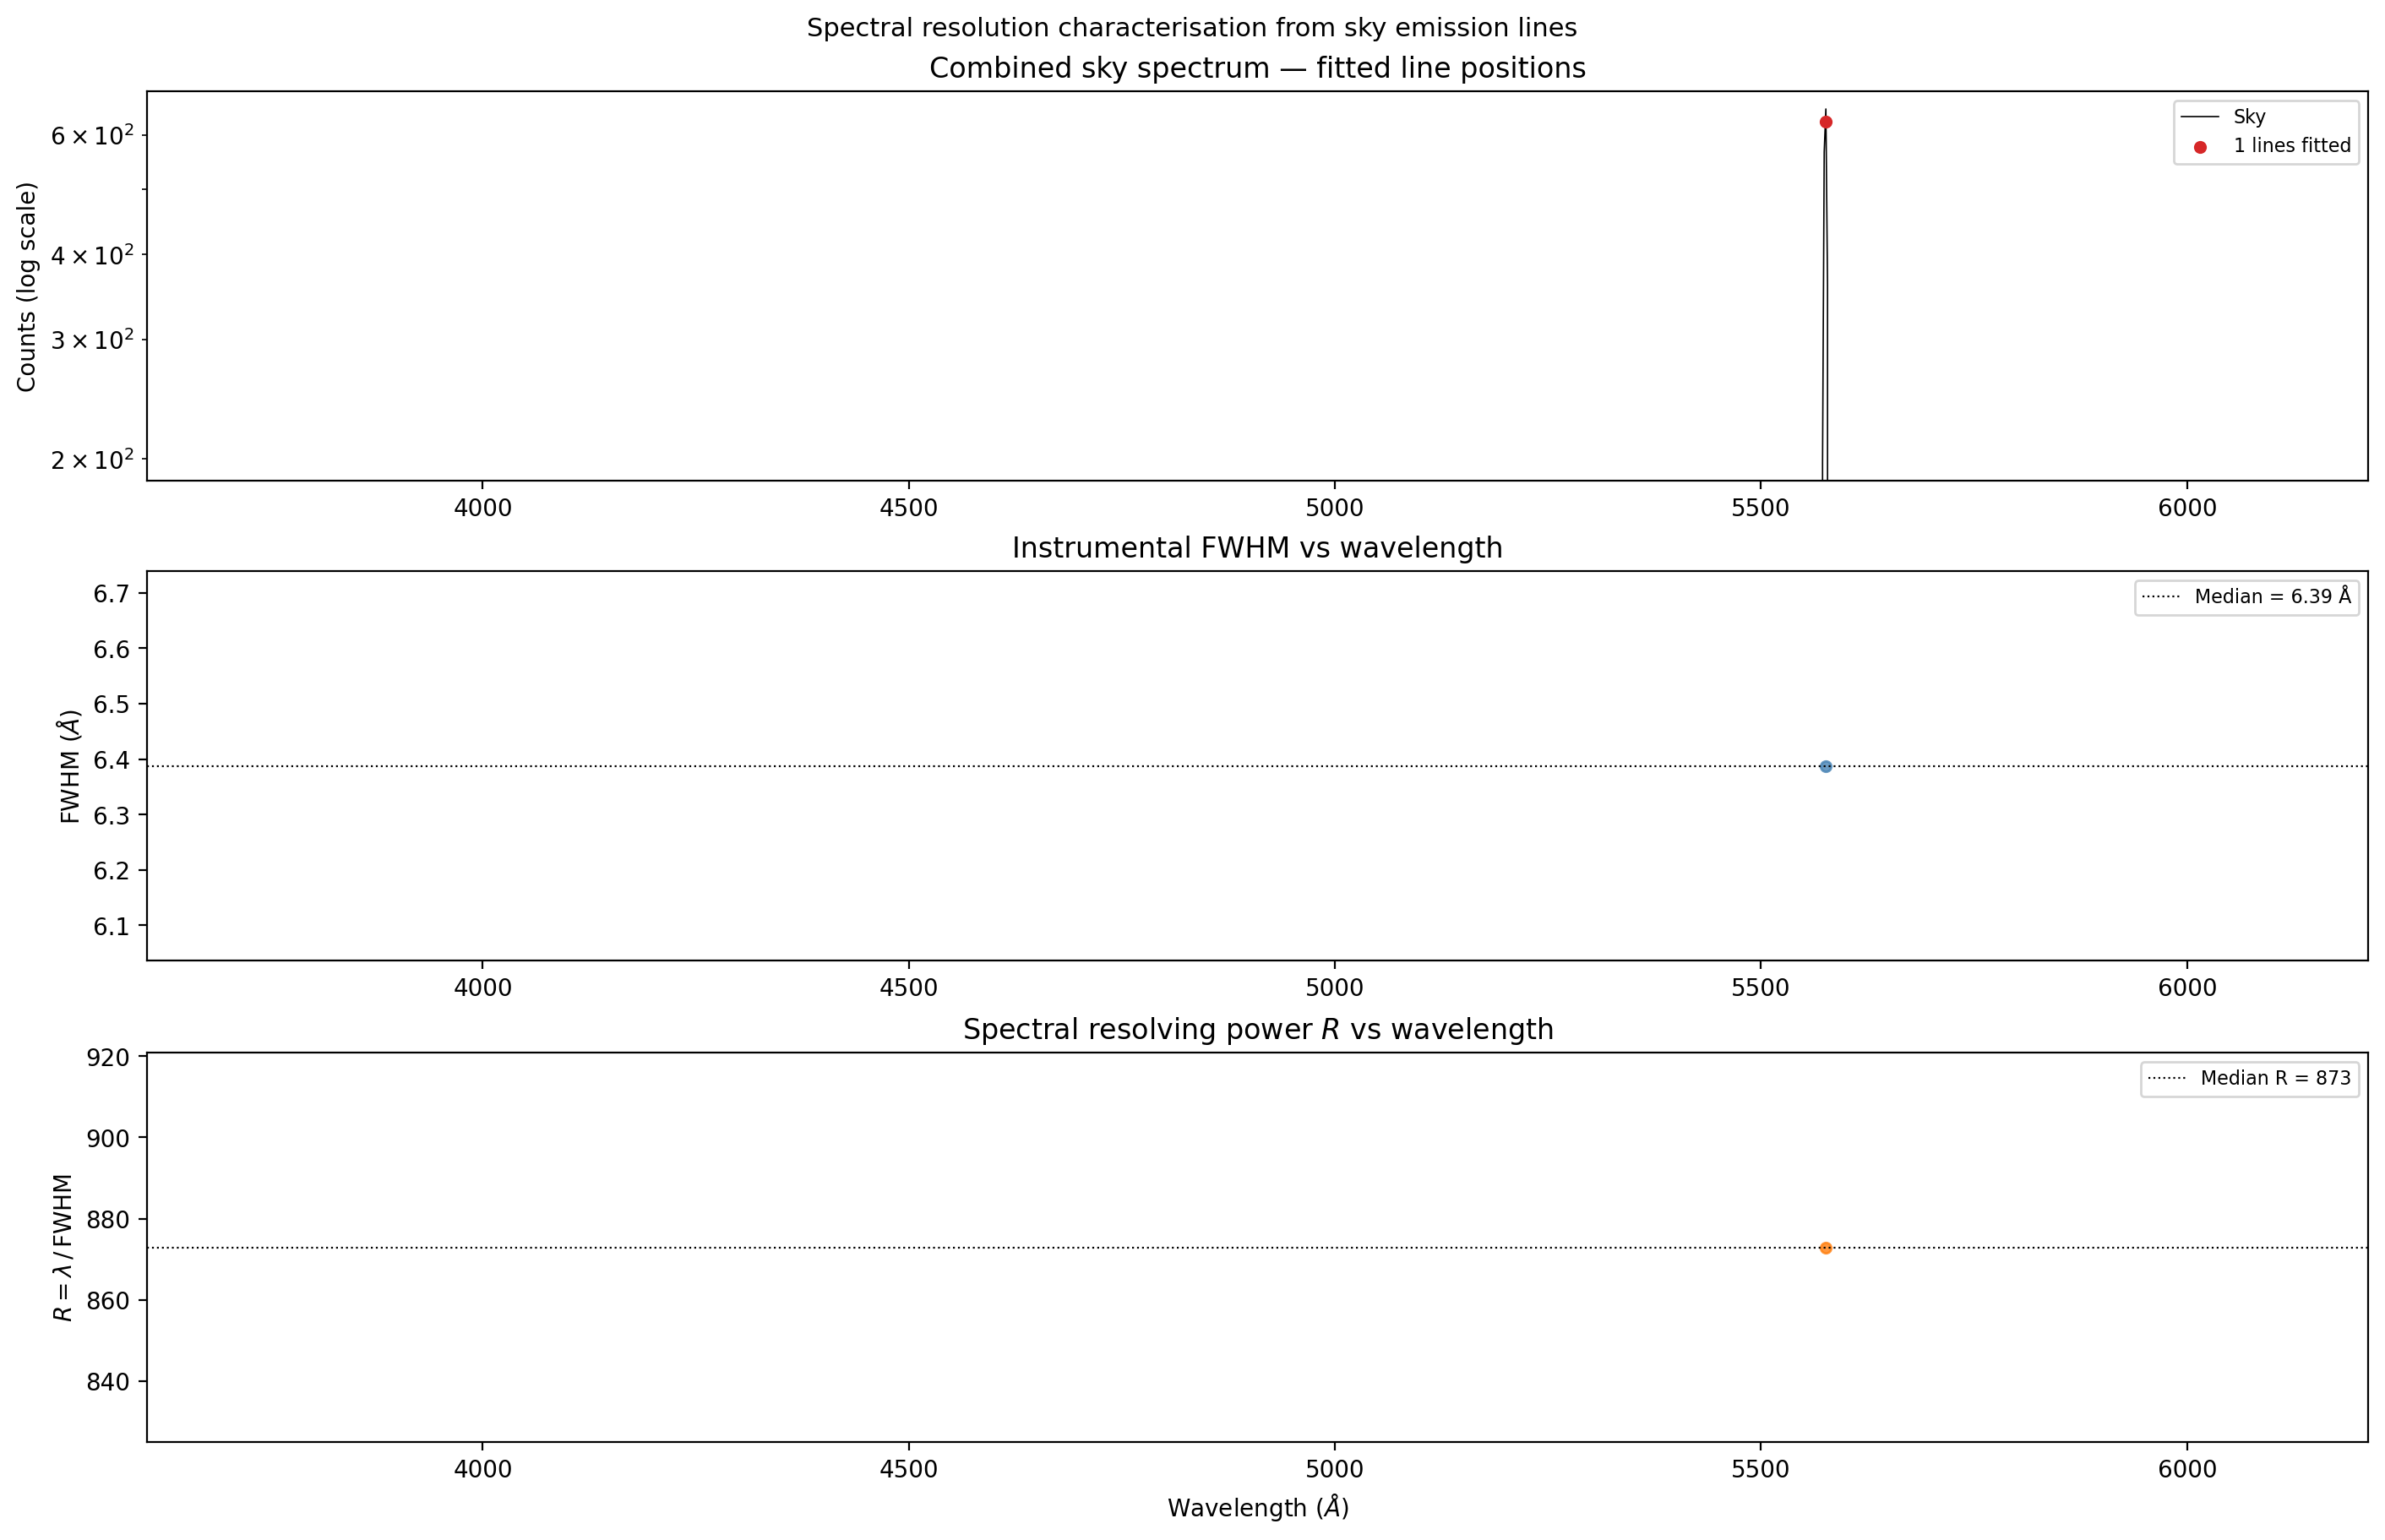

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# Spectral resolution trend
# Measure FWHM by fitting Gaussians to bright sky emission lines in the
# combined SKY spectrum.  Derive R(λ) = λ / FWHM(λ).
# ─────────────────────────────────────────────────────────────────────────────
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

job = obj_jobs[0]

with fits.open(job["red"]) as hdul:
    sky_res = hdul["SKY"].data.astype(float)

sky_clean = np.where(np.isfinite(sky_res), sky_res, 0.0)
sky_norm  = sky_clean / (np.nanmax(sky_clean) or 1.0)

# Detect peaks: at least 2 % of maximum, min separation 15 px, prominence 1 %
peaks, _ = find_peaks(sky_norm, height=0.02, distance=15, prominence=0.01)


def _gaussian(x, amp, mu, sigma, base):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + base


fwhm_list = []
wave_list = []

for pk in peaks:
    hw = 8
    lo, hi = max(0, pk - hw), min(len(wave), pk + hw)
    xdata = wave[lo:hi]
    ydata = sky_clean[lo:hi]
    if len(xdata) < 5 or np.max(ydata) <= 0:
        continue
    try:
        p0     = [np.max(ydata), wave[pk], 1.5, np.min(ydata)]
        bounds = ([0, wave[pk] - 5, 0.3, -np.inf], [np.inf, wave[pk] + 5, 8.0, np.inf])
        popt, _ = curve_fit(_gaussian, xdata, ydata, p0=p0, bounds=bounds, maxfev=1200)
        fwhm_fit = 2.3548 * abs(popt[2])   # 2√(2 ln 2) × σ
        if 0.5 < fwhm_fit < 15.0:
            fwhm_list.append(fwhm_fit)
            wave_list.append(popt[1])
    except RuntimeError:
        continue

fwhm_arr = np.array(fwhm_list)
wave_arr  = np.array(wave_list)

print(f"Fitted {len(fwhm_arr)} sky-emission lines")
if len(fwhm_arr) > 0:
    print(f"  Median FWHM = {np.median(fwhm_arr):.2f} Å")
    print(f"  Median R    = {np.median(wave_arr / fwhm_arr):.0f}")

# ── Plot ──
fig, axes = plt.subplots(3, 1, figsize=(14, 9), constrained_layout=True)
fig.suptitle("Spectral resolution characterisation from sky emission lines", fontsize=11)

# Top: sky spectrum with detected peak positions marked
ax = axes[0]
valid_sky = np.isfinite(sky_res)
ax.plot(wave[valid_sky], sky_res[valid_sky], "k-", lw=0.6, label="Sky")
if len(wave_arr) > 0:
    ax.scatter(
        wave_arr, np.interp(wave_arr, wave[valid_sky], sky_res[valid_sky]),
        s=20, c="tab:red", zorder=5, label=f"{len(wave_arr)} lines fitted",
    )
ax.set_yscale("log")
ax.set_ylabel("Counts (log scale)")
ax.set_title("Combined sky spectrum — fitted line positions")
ax.legend(fontsize=8)
ax.set_xlim(wave[0], wave[-1])

# Middle: FWHM vs wavelength
ax = axes[1]
if len(fwhm_arr) > 0:
    ax.scatter(wave_arr, fwhm_arr, s=20, c="steelblue", alpha=0.8)
    if len(fwhm_arr) >= 3:
        poly1 = np.polyfit(wave_arr, fwhm_arr, 1)
        w_trend = np.linspace(wave[0], wave[-1], 300)
        ax.plot(
            w_trend, np.polyval(poly1, w_trend), "r--", lw=1.2,
            label=f"Linear fit: {poly1[0]:.5f}λ + {poly1[1]:.2f} Å",
        )
    ax.axhline(np.median(fwhm_arr), color="k", lw=0.8, ls=":", label=f"Median = {np.median(fwhm_arr):.2f} Å")
    ax.set_ylabel(r"FWHM ($\AA$)")
    ax.set_title("Instrumental FWHM vs wavelength")
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, "No lines measured", transform=ax.transAxes, ha="center")
ax.set_xlim(wave[0], wave[-1])

# Bottom: spectral resolving power R(λ)
ax = axes[2]
if len(fwhm_arr) > 0:
    R_arr = wave_arr / fwhm_arr
    ax.scatter(wave_arr, R_arr, s=20, c="tab:orange", alpha=0.8)
    ax.axhline(np.median(R_arr), color="k", lw=0.8, ls=":",
               label=f"Median R = {np.median(R_arr):.0f}")
    ax.set_ylabel(r"$R = \lambda\,/\,\mathrm{FWHM}$")
    ax.set_title(r"Spectral resolving power $R$ vs wavelength")
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, "No lines measured", transform=ax.transAxes, ha="center")
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_xlim(wave[0], wave[-1])

plt.show()